# Libraries & Dependencies

In [1]:
# ! pip install uv 
# ! uv pip install numpy scipy scikit-learn pandas torch torch-geometric rdkit pyyaml PyTDC
# conda install -c conda-forge pytdc

In [2]:
import re
import json
import logging

from typing import List, Dict, Union, Tuple, Optional, Set

import numpy as np
import torch
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, rdFingerprintGenerator
from torch_geometric.data import Data
from torch.utils.data import Dataset, DataLoader

import os
import yaml
import pandas as pd
from tdc.single_pred import ADME, Tox
from tdc.generation import MolGen

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_add_pool

import torch.optim as optim
from sklearn.metrics import roc_auc_score, mean_absolute_error, average_precision_score
from scipy.stats import spearmanr
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader as TorchDataLoader
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GCNConv, global_add_pool

try:
    from torch_geometric.data import Data
    HAS_PYG = True
except ImportError:
    HAS_PYG = False

import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker

In [3]:
torch.set_num_threads(8)

In [4]:
RDLogger.DisableLog('rdApp.*')

In [5]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger("Data")

# Data Preparation

In [6]:
class SMILESTokenizer:
    """
    Regex-based tokenizer for chemical formulas.
    Essential for Sequence models (CNN, Mamba).
    """
    def __init__(self, vocab_file: str = None, max_len: int = 128):
        self.max_len = max_len
        self.pad_token = "<pad>"
        self.unk_token = "<unk>"
        self.sos_token = "<sos>"
        self.eos_token = "<eos>"
        self.token_pattern = re.compile(r"(\[[^\]]+]|Br?|Cl?|N|O|S|"
            "P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\\\|\/|:|~|@|\?|>|\*|\$|\%[0-9]{2}|[0-9])")
        
        if vocab_file:
            self.load_vocab(vocab_file)
        else:
            self.vocab = {
                self.pad_token: 0,
                self.sos_token: 1,
                self.eos_token: 2,
                self.unk_token: 3
            }
            self.inverse_vocab = {v: k for k, v in self.vocab.items()}

    def train(self, smiles_list: List[str]):
        """Build vocabulary from a list of SMILES."""
        unique_tokens = set()
        for smi in smiles_list:
            tokens = self.token_pattern.findall(smi)
            unique_tokens.update(tokens)
        
        start_idx = len(self.vocab)
        for i, token in enumerate(sorted(unique_tokens)):
            self.vocab[token] = start_idx + i
            
        self.inverse_vocab = {v: k for k, v in self.vocab.items()}
        logger.info(f"Tokenizer trained. Vocab size: {len(self.vocab)}")

    def encode(self, smiles: str) -> torch.Tensor:
        """SMILES -> LongTensor [max_len]"""
        tokens = self.token_pattern.findall(smiles)
        ids = [self.vocab.get(t, self.vocab[self.unk_token]) for t in tokens]
        ids = [self.vocab[self.sos_token]] + ids + [self.vocab[self.eos_token]]
        
        if len(ids) < self.max_len:
            ids += [self.vocab[self.pad_token]] * (self.max_len - len(ids))
        else:
            ids = ids[:self.max_len-1] + [self.vocab[self.eos_token]]
            
        return torch.tensor(ids, dtype=torch.long)

    def save_vocab(self, path: str):
        with open(path, 'w') as f:
            json.dump(self.vocab, f)

    def load_vocab(self, path: str):
        with open(path, 'r') as f:
            self.vocab = json.load(f)
        self.inverse_vocab = {v: k for k, v in self.vocab.items()}

    def __len__(self):
        return len(self.vocab)

In [7]:
class MolFeaturizer:
    """Factory class to generate different molecular representations."""
    
    @staticmethod
    def smiles_to_morgan(smiles: str, radius: int = 2, n_bits: int = 2048) -> torch.Tensor:
        """Generates Morgan Fingerprint (ECFP)."""
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return torch.zeros(n_bits)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
        arr = np.zeros((0,), dtype=np.int8)
        Chem.DataStructs.ConvertToNumpyArray(fp, arr)
        return torch.tensor(arr, dtype=torch.float32)

    @staticmethod
    def smiles_to_graph(smiles: str) -> Data:
        """
        Generates PyTorch Geometric Data object.
        Simple node features: AtomicNum (one-hot or integer).
        """
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return Data(x=torch.zeros((1, 1)), edge_index=torch.zeros((2, 0)))
        atom_features = []
        for atom in mol.GetAtoms():
            atom_features.append(atom.GetAtomicNum())
        
        x = torch.tensor(atom_features, dtype=torch.long).unsqueeze(1) # [N, 1]
        rows, cols = [], []
        for bond in mol.GetBonds():
            start = bond.GetBeginAtomIdx()
            end = bond.GetEndAtomIdx()
            rows.extend([start, end])
            cols.extend([end, start])
            
        edge_index = torch.tensor([rows, cols], dtype=torch.long)
        
        return Data(x=x, edge_index=edge_index)

In [8]:
class MolecularDataset(Dataset):
    def __init__(self, smiles_list, labels, featurizer):
        """
        Обновленный класс: принимает featurizer (функцию/объект), 
        а не строку modality.
        """
        self.smiles = smiles_list
        self.labels = labels
        self.featurizer = featurizer

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        smi = self.smiles[idx]
        label = self.labels[idx]
        x = self.featurizer(smi)
        if label is None or np.isnan(label): 
            label = 0.0 
            
        y = torch.tensor([label], dtype=torch.float32)
        
        return x, y

In [9]:
DATA_DIR = "data"
RAW_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
TOKENIZER_PATH = os.path.join(DATA_DIR, "tokenizer.json")
MAX_SEQ_LEN = 128  # Максимальная длина SMILES


def ensure_dirs():
    if not os.path.exists(RAW_DIR):
        os.makedirs(RAW_DIR)
    if not os.path.exists(PROCESSED_DIR):
        os.makedirs(PROCESSED_DIR)

def process_and_download_all():
    ensure_dirs()
    
    logger.info("Downloading ZINC for pretraining...")
    data = MolGen(name='ZINC', path=RAW_DIR) 
    split = data.get_split()
    
    train_smiles = split['train']['smiles'][:250000].tolist()
    
    logger.info(f"ZINC loaded. Using {len(train_smiles)} molecules for tokenizer training.")

    logger.info("Training Tokenizer...")
    tokenizer = SMILESTokenizer(max_len=MAX_SEQ_LEN)
    tokenizer.train(train_smiles)
    tokenizer.save_vocab(TOKENIZER_PATH)
    logger.info(f"Tokenizer saved to {TOKENIZER_PATH}")
    logger.info(f"Vocab size: {len(tokenizer.vocab)}")

    tasks = {
        'Caco2_Wang': 'Caco2',
        'HIA_Hou': 'HIA',
        'Pgp_Broccatelli': 'Pgp',
        'Bioavailability_Ma': 'Bioav',
        'Lipophilicity_AstraZeneca': 'Lipo',
        'Solubility_AqSolDB': 'AqSol'
    }
    
    for tdc_name, paper_name in tasks.items():
        logger.info(f"Downloading downstream task: {paper_name} ({tdc_name})...")
        try:
            data = ADME(name=tdc_name, path=RAW_DIR)
            split = data.get_split(method='scaffold', seed=42, frac=[0.8, 0.1, 0.1])
            
            save_task_dir = os.path.join(PROCESSED_DIR, paper_name)
            os.makedirs(save_task_dir, exist_ok=True)
            
            split['train'].to_csv(os.path.join(save_task_dir, 'train.csv'), index=False)
            split['valid'].to_csv(os.path.join(save_task_dir, 'val.csv'), index=False)
            split['test'].to_csv(os.path.join(save_task_dir, 'test.csv'), index=False)
            
            logger.info(f"Task {paper_name} processed and saved to {save_task_dir}")
            
        except Exception as e:
            logger.error(f"Error downloading {paper_name}: {e}")



In [11]:
process_and_download_all()

2026-04-18 15:37:49,180 - INFO - Downloading ZINC for pretraining...
Downloading...
100%|██████████| 11.8M/11.8M [00:05<00:00, 2.05MiB/s]
Loading...
Done!
2026-04-18 15:37:57,122 - INFO - ZINC loaded. Using 174618 molecules for tokenizer training.
2026-04-18 15:37:57,123 - INFO - Training Tokenizer...
2026-04-18 15:37:58,269 - INFO - Tokenizer trained. Vocab size: 62
2026-04-18 15:37:58,270 - INFO - Tokenizer saved to data/tokenizer.json
2026-04-18 15:37:58,270 - INFO - Vocab size: 62
2026-04-18 15:37:58,271 - INFO - Downloading downstream task: Caco2 (Caco2_Wang)...
Downloading...
100%|██████████| 82.5k/82.5k [00:00<00:00, 286kiB/s]
Loading...
Done!
100%|██████████| 910/910 [00:00<00:00, 1802.81it/s]
2026-04-18 15:38:00,750 - INFO - Task Caco2 processed and saved to data/processed/Caco2
2026-04-18 15:38:00,750 - INFO - Downloading downstream task: HIA (HIA_Hou)...
Downloading...
100%|██████████| 40.1k/40.1k [00:00<00:00, 186kiB/s] 
Loading...
Done!
100%|██████████| 578/578 [00:00<00:0

# Feature Engineering

In [10]:
class MorganFeaturizer:
    def __init__(self, radius=2, n_bits=1024):
        self.generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
        self.n_bits = n_bits
        
    def __call__(self, smiles):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return torch.zeros(self.n_bits)
        return torch.tensor(self.generator.GetFingerprintAsNumPy(mol), dtype=torch.float32)

In [11]:
class GraphFeaturizer:
    def __call__(self, smiles: str):
        if not HAS_PYG: 
            print("Библиотека torch_geometric не установлена!")
            return None
            
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            # Заглушка тоже должна быть (1, 9)
            return Data(x=torch.zeros((1, 9)), edge_index=torch.empty((2, 0), dtype=torch.long))

        # Атомы
        atom_features =[]
        for atom in mol.GetAtoms():
            # Базовые 5 фич
            feats =[
                atom.GetAtomicNum(),
                atom.GetDegree(),
                atom.GetExplicitValence(),
                int(atom.GetIsAromatic()),
                atom.GetFormalCharge()
            ]
            
            # ИСПРАВЛЕНИЕ: Дополняем нулями до 9, чтобы совпадало с GCN(node_features=9)
            padding = [0] * (9 - len(feats))
            feats += padding
            
            atom_features.append(feats)
            
        x = torch.tensor(atom_features, dtype=torch.float32)

        # Связи
        rows, cols = [],[]
        for bond in mol.GetBonds():
            start = bond.GetBeginAtomIdx()
            end = bond.GetEndAtomIdx()
            rows.extend([start, end])
            cols.extend([end, start])

        if len(rows) == 0:
            edge_index = torch.empty((2, 0), dtype=torch.long)
        else:
            edge_index = torch.tensor([rows, cols], dtype=torch.long)

        return Data(x=x, edge_index=edge_index)

In [12]:
class CharTokenizer:
    """
    Modality 3: Sequence (for SMILES-CNN, Mamba)
    Character-level tokenization.
    """
    def __init__(self, max_len: int = 128, vocab_path: Optional[str] = None):
        self.max_len = max_len
        self.pad_token = "<pad>"
        self.sos_token = "<sos>"
        self.eos_token = "<eos>"
        self.unk_token = "<unk>"
        
        base_chars = [
            'C', 'c', 'O', 'o', 'N', 'n', 'S', 's',
            '=', '#', '(', ')', '[', ']', '1', '2', '3', 
            '+', '-', '.', 'F', 'Cl', 'Br', 'I', 'H'
        ]
        
        self.vocab = {
            self.pad_token: 0,
            self.sos_token: 1,
            self.eos_token: 2,
            self.unk_token: 3
        }
        
        for char in base_chars:
            if char not in self.vocab:
                self.vocab[char] = len(self.vocab)
                
        self.inverse_vocab = {v: k for k, v in self.vocab.items()}
        
        if vocab_path:
            self.load_vocab(vocab_path)

    def fit_on_zinc(self, smiles_list: List[str]):
        """
        Scans ZINC dataset to add missing characters (e.g., '4', '5', 'P', '/', '\')
        to the vocabulary to ensure coverage.
        """
        unique_chars = set()
        for smi in smiles_list:
            unique_chars.update(list(smi))
            
        for char in sorted(list(unique_chars)):
            if char not in self.vocab:
                self.vocab[char] = len(self.vocab)
        
        self.inverse_vocab = {v: k for k, v in self.vocab.items()}
        print(f"Tokenizer fitted. Vocab size: {len(self.vocab)}")

    def encode(self, smiles: str) -> torch.Tensor:
        """
        Process: String -> List[Int] -> Pad/Truncate -> Tensor
        """
        chars = list(smiles)
        
        ids = [self.vocab.get(c, self.vocab[self.unk_token]) for c in chars]
        
        ids = [self.vocab[self.sos_token]] + ids + [self.vocab[self.eos_token]]
        
        if len(ids) < self.max_len:
            padding = [self.vocab[self.pad_token]] * (self.max_len - len(ids))
            ids = ids + padding
        else:
            ids = ids[:self.max_len - 1] + [self.vocab[self.eos_token]]
            
        return torch.tensor(ids, dtype=torch.long)

    def save_vocab(self, path: str):
        with open(path, 'w') as f:
            json.dump(self.vocab, f)
            
    def load_vocab(self, path: str):
        with open(path, 'r') as f:
            self.vocab = json.load(f)
        self.inverse_vocab = {v: k for k, v in self.vocab.items()}

In [13]:
smi = "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"

morgan = MorganFeaturizer(radius=2, n_bits=1024)
print(f"Morgan Shape: {morgan(smi).shape}")

graph_gen = GraphFeaturizer()
graph_data = graph_gen(smi)
print(f"Graph Nodes: {graph_data.x.shape}")
print(f"Graph Edges: {graph_data.edge_index.shape}")

tokenizer = CharTokenizer(max_len=128)
tokens = tokenizer.encode(smi)
print(f"Tokens Shape: {tokens.shape}")
print(f"Tokens: {tokens[:15]}")

Morgan Shape: torch.Size([1024])
Graph Nodes: torch.Size([14, 9])
Graph Edges: torch.Size([2, 30])
Tokens Shape: torch.Size([128])
Tokens: tensor([ 1,  4,  8, 18,  4, 12,  8,  4, 19, 12,  4, 18,  4, 14, 12])


# Models

In [14]:
class BaseModel(nn.Module):
    """Base class with utility to count parameters."""
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


In [15]:
# ==========================================
# Baseline 1: Morgan + MLP
# ==========================================
class MorganMLP(BaseModel):
    def __init__(self, input_dim=1024, output_dim=1, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [16]:
MorganMLP()

MorganMLP(
  (net): Sequential(
    (0): Linear(in_features=1024, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=512, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [17]:
# ==========================================
# Baseline 2: SMILES + CNN
# ==========================================
class SmilesCNN(BaseModel):
    def __init__(self, vocab_size, embed_dim=64, output_dim=1, max_len=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.conv1 = nn.Conv1d(in_channels=embed_dim, out_channels=32, kernel_size=4)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=6)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=96, kernel_size=8)
        
        self.mlp = nn.Sequential(
            nn.Linear(96, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = x.transpose(1, 2)
        
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        
        x = torch.max(x, dim=2)[0]
        
        return self.mlp(x)

In [18]:
SmilesCNN(64)

SmilesCNN(
  (embedding): Embedding(64, 64, padding_idx=0)
  (conv1): Conv1d(64, 32, kernel_size=(4,), stride=(1,))
  (conv2): Conv1d(32, 64, kernel_size=(6,), stride=(1,))
  (conv3): Conv1d(64, 96, kernel_size=(8,), stride=(1,))
  (mlp): Sequential(
    (0): Linear(in_features=96, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [19]:
# ==========================================
# Baseline 3: GCN
# ==========================================
class GCN(nn.Module):
    def __init__(self, node_features=9, hidden_dim=100):
        super().__init__()
        self.convs = nn.ModuleList([GCNConv(node_features, hidden_dim)])
        for _ in range(4): self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.head = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
        x = global_add_pool(x, batch)
        return self.head(x)

In [20]:
GCN()

GCN(
  (convs): ModuleList(
    (0): GCNConv(9, 100)
    (1-4): 4 x GCNConv(100, 100)
  )
  (head): Linear(in_features=100, out_features=1, bias=True)
)

In [21]:
# ==========================================
# Baseline 4: NeuralFP (Frozen Encoder)
# ==========================================
class NeuralFP(BaseModel):
    def __init__(self, pretrained_gcn: GCN, output_dim=1):
        super().__init__()
        self.encoder = pretrained_gcn

        hidden_dim = pretrained_gcn.head.in_features 
        
        self.encoder.head = nn.Identity()
        
        for param in self.encoder.parameters():
            param.requires_grad = False
        
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 200), 
            nn.ReLU(),
            nn.Linear(200, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, output_dim)
        )

    def forward(self, data):
        with torch.no_grad():
            embedding = self.encoder(data)

        return self.decoder(embedding)
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [22]:
NeuralFP(GCN())

NeuralFP(
  (encoder): GCN(
    (convs): ModuleList(
      (0): GCNConv(9, 100)
      (1-4): 4 x GCNConv(100, 100)
    )
    (head): Identity()
  )
  (decoder): Sequential(
    (0): Linear(in_features=100, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=50, bias=True)
    (5): ReLU()
    (6): Linear(in_features=50, out_features=1, bias=True)
  )
)

In [23]:
class Mamba3CPUBlock(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2, num_heads=2):
        super().__init__()
        self.d_model = d_model
        self.d_inner = int(expand * d_model)
        self.d_state = d_state
        self.num_heads = num_heads
        
        self.in_proj = nn.Linear(d_model, self.d_inner * 2)
        
        self.conv1d = nn.Conv1d(
            in_channels=self.d_inner,
            out_channels=self.d_inner,
            kernel_size=d_conv,
            padding=d_conv - 1,
            groups=self.d_inner
        )

        A_real = -torch.exp(torch.randn(num_heads, d_state))
        A_imag = torch.randn(num_heads, d_state)
        self.A_real = nn.Parameter(A_real)
        self.A_imag = nn.Parameter(A_imag)
        
        self.x_proj = nn.Linear(self.d_inner, num_heads * d_state * 4 + num_heads)
        
        self.D = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj = nn.Linear(self.d_inner, d_model)

    def forward(self, x):
        B_batch, L, _ = x.shape
        
        x_proj = self.in_proj(x)
        x_mimo, res = x_proj.chunk(2, dim=-1)
        
        x_conv = x_mimo.transpose(1, 2)
        x_conv = self.conv1d(x_conv)[:, :, :L]
        x_conv = x_conv.transpose(1, 2)
        x_conv = F.silu(x_conv)
        
        x_dbl = self.x_proj(x_conv)

        splits =[
            self.num_heads,                   # dt
            self.num_heads * self.d_state,    # B_real
            self.num_heads * self.d_state,    # B_imag
            self.num_heads * self.d_state,    # C_real
            self.num_heads * self.d_state     # C_imag
        ]
        dt_mimo, B_real, B_imag, C_real, C_imag = torch.split(x_dbl, splits, dim=-1)
        
        dt = F.softplus(dt_mimo) # (Batch, L, num_heads)
        y = self._cpu_complex_scan(x_conv, dt, B_real, B_imag, C_real, C_imag)
        
        # Residual MIMO connection
        y = y + x_mimo * self.D
        y = y * F.silu(res)
        return self.out_proj(y)

    def _cpu_complex_scan(self, x, dt, B_real, B_imag, C_real, C_imag):
        B_batch, L, D_inner = x.shape
        H = self.num_heads
        S = self.d_state
        Dh = D_inner // H

        # reshape безопасно
        x_heads = x.reshape(B_batch, L, H, Dh)

        B_real = B_real.reshape(B_batch, L, H, S)
        B_imag = B_imag.reshape(B_batch, L, H, S)
        C_real = C_real.reshape(B_batch, L, H, S)
        C_imag = C_imag.reshape(B_batch, L, H, S)

        A_real = self.A_real  # (H, S)
        A_imag = self.A_imag  # (H, S)

        dt = dt.unsqueeze(-1)  # (B, L, H, 1)

        # exp(dt * (a+ib)) = exp(dt*a) * (cos(dt*b) + i sin(dt*b))
        exp_real = torch.exp(dt * A_real)              # (B, L, H, S)
        cos_term = torch.cos(dt * A_imag)
        sin_term = torch.sin(dt * A_imag)

        dA_real = exp_real * cos_term
        dA_imag = exp_real * sin_term

        dB_real = dt * B_real
        dB_imag = dt * B_imag

        # состояние (реальная и мнимая части)
        h_real = torch.zeros((B_batch, H, S, Dh), device=x.device)
        h_imag = torch.zeros((B_batch, H, S, Dh), device=x.device)

        ys = []

        for t in range(L):
            # --- h = A*h + B*x ---
            # (a+ib)(c+id)
            # real = ac - bd
            # imag = ad + bc

            Ar = dA_real[:, t].unsqueeze(-1)
            Ai = dA_imag[:, t].unsqueeze(-1)

            Br = dB_real[:, t].unsqueeze(-1)
            Bi = dB_imag[:, t].unsqueeze(-1)

            x_t = x_heads[:, t].unsqueeze(-2)

            new_h_real = Ar * h_real - Ai * h_imag + Br * x_t
            new_h_imag = Ar * h_imag + Ai * h_real + Bi * x_t

            h_real, h_imag = new_h_real, new_h_imag

            # --- y = C* h ---
            Cr = C_real[:, t].unsqueeze(-1)
            Ci = C_imag[:, t].unsqueeze(-1)

            y_real = (Cr * h_real + Ci * h_imag).sum(dim=2)

            ys.append(y_real)

        y = torch.stack(ys, dim=1)
        return y.reshape(B_batch, L, D_inner)

In [24]:
class Mamba3Backbone(BaseModel):
    def __init__(self, vocab_size, d_model=128, n_layers=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.layers = nn.ModuleList([
            Mamba3CPUBlock(d_model=d_model) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        for layer in self.layers:
            x = layer(x)
        return self.norm(x) # (Batch, Seq_Len, d_model)

class Mamba3ForPretraining(BaseModel):
    def __init__(self, backbone, vocab_size):
        super().__init__()
        self.backbone = backbone
        self.lm_head = nn.Linear(backbone.norm.normalized_shape[0], vocab_size, bias=False)

    def forward(self, input_ids):
        hidden_states = self.backbone(input_ids)
        logits = self.lm_head(hidden_states)
        return logits # (Batch, Seq_Len, vocab_size)

class Mamba3ForADMET(BaseModel):
    def __init__(self, backbone, n_classes=1):
        super().__init__()
        self.backbone = backbone
        self.clf_head = nn.Linear(backbone.norm.normalized_shape[0], n_classes)

    def forward(self, input_ids):
        hidden_states = self.backbone(input_ids)
        mask = (input_ids != 0).float().unsqueeze(-1)
        pooled = (hidden_states * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        return self.clf_head(pooled)

In [25]:
Mamba3CPUBlock(128)

Mamba3CPUBlock(
  (in_proj): Linear(in_features=128, out_features=512, bias=True)
  (conv1d): Conv1d(256, 256, kernel_size=(4,), stride=(1,), padding=(3,), groups=256)
  (x_proj): Linear(in_features=256, out_features=130, bias=True)
  (out_proj): Linear(in_features=256, out_features=128, bias=True)
)

In [26]:
Mamba3Backbone(128)

Mamba3Backbone(
  (embedding): Embedding(128, 128, padding_idx=0)
  (layers): ModuleList(
    (0-3): 4 x Mamba3CPUBlock(
      (in_proj): Linear(in_features=128, out_features=512, bias=True)
      (conv1d): Conv1d(256, 256, kernel_size=(4,), stride=(1,), padding=(3,), groups=256)
      (x_proj): Linear(in_features=256, out_features=130, bias=True)
      (out_proj): Linear(in_features=256, out_features=128, bias=True)
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
)

# Pretraining

In [27]:
CFG_PRETRAIN = {
    'device': "cpu",
    'data_path': RAW_DIR,
    'vocab_save_path': TOKENIZER_PATH,
    'backbone_save_path': 'mamba_backbone.pth',
    'n_samples': 32_768,
    'epochs': 10,
    'batch_size': 256,
    'lr': 1e-3,
    'augment_prob': 0.5, 
}

def randomize_smiles(smiles: str, n_tries: int = 3) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles
    
    for _ in range(n_tries):
        atom_order = list(range(mol.GetNumAtoms()))
        random.shuffle(atom_order)
        shuffled_mol = Chem.RenumberAtoms(mol, atom_order)
        rand_smi = Chem.MolToSmiles(shuffled_mol, canonical=False)
        if rand_smi:
            return rand_smi
    
    return smiles

class PretrainSMILESDataset(Dataset):
    def __init__(self, smiles_list, tokenizer, augment_prob=0.5):
        self.smiles       = self._filter_valid(smiles_list)
        self.tokenizer    = tokenizer
        self.augment_prob = augment_prob
        
        self.tokens = []
        for smi in tqdm(self.smiles, desc="Tokenizing"):
            self.tokens.append(self.tokenizer.encode(smi))
        logger.info(f"Done. {len(self.tokens)} sequences ready.")


    @staticmethod
    def _filter_valid(smiles_list: list) -> list:
        valid = []
        invalid = 0
        for smi in smiles_list:
            if Chem.MolFromSmiles(smi) is not None:
                valid.append(smi)
            else:
                invalid += 1
        return valid

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        if self.augment_prob > 0 and random.random() < self.augment_prob:
            smi    = randomize_smiles(self.smiles[idx])
            tokens = self.tokenizer.encode(smi)
        else:
            tokens = self.tokens[idx]
        
        x = tokens[:-1]
        y = tokens[1:]
        return (
            torch.tensor(x, dtype=torch.long),
            torch.tensor(y, dtype=torch.long),
        )


In [28]:
class PadCollate:
    def __init__(self, pad_idx: int):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        xs, ys = zip(*batch)

        xs = [x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.long) for x in xs]
        ys = [y if isinstance(y, torch.Tensor) else torch.tensor(y, dtype=torch.long) for y in ys]
        
        max_len = max(x.size(0) for x in xs)
        
        x_pad = torch.full((len(xs), max_len), self.pad_idx, dtype=torch.long)
        y_pad = torch.full((len(ys), max_len), self.pad_idx, dtype=torch.long)
        
        for i, (x, y) in enumerate(zip(xs, ys)):
            x_pad[i, :x.size(0)] = x
            y_pad[i, :y.size(0)] = y
        
        return x_pad, y_pad

In [29]:
def run_pretraining(
    train_smiles : list[str],
    tokenizer,
    device,
    save_path: str = "mamba_backbone.pth",
    epochs: int = 10,
    batch_size: int = 128,
    lr: float = 1e-3,
    augment_prob: float = 0.5,
):
    vocab_size = len(tokenizer.vocab)
    pad_idx    = tokenizer.vocab.get(tokenizer.pad_token, 0)

    backbone = Mamba3Backbone(vocab_size=vocab_size, d_model=64, n_layers=2)
    model    = Mamba3ForPretraining(backbone=backbone, vocab_size=vocab_size)
    model    = model.to(device)

    dataset = PretrainSMILESDataset(
        train_smiles,
        tokenizer,
        augment_prob=augment_prob,
    )

    num_workers = 0 if device.type == "cpu" else 4
    
    loader = DataLoader(
        dataset,
        batch_size  = batch_size,
        shuffle     = True,
        drop_last   = True,
        num_workers = num_workers,
        pin_memory  = device.type == "cuda",
        collate_fn  = PadCollate(pad_idx),
    )

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=0.01
    )
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr          = lr,
        epochs          = epochs,
        steps_per_epoch = len(loader),
    )
    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

    best_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        total_loss   = 0.0
        total_tokens = 0
        
        pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            logits = model(x)
            
            loss = criterion(
                logits.view(-1, vocab_size),
                y.view(-1),
            )
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            n_tokens      = (y != pad_idx).sum().item()
            total_loss   += loss.item() * n_tokens
            total_tokens += n_tokens
            
            pbar.set_postfix(
                loss=f"{loss.item():.4f}",
                lr  =f"{scheduler.get_last_lr()[0]:.2e}",
            )

        avg_loss   = total_loss / max(total_tokens, 1)
        perplexity = np.exp(avg_loss)
        
        logger.info(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {avg_loss:.4f} | "
            f"Perplexity: {perplexity:.2f}"
        )
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(backbone.state_dict(), save_path)
            logger.info(f"  ✓ Best model saved → {save_path}")

In [30]:
def pretrain_mamba_pipeline():
    device = torch.device(CFG_PRETRAIN['device'])
    tokenizer = SMILESTokenizer(max_len=MAX_SEQ_LEN)
    
    if os.path.exists(CFG_PRETRAIN['vocab_save_path']):
        tokenizer.load_vocab(CFG_PRETRAIN['vocab_save_path'])
        logger.info(f"Tokenizer loaded, vocab={len(tokenizer.vocab)}")
    else:
        zinc_data   = MolGen(name='ZINC', path=CFG_PRETRAIN['data_path'])
        zinc_smiles = (
            zinc_data
            .get_split()['train']['smiles']
            [:CFG_PRETRAIN['n_samples']]
            .tolist()
        )
        tokenizer.train(zinc_smiles)
        tokenizer.save_vocab(CFG_PRETRAIN['vocab_save_path'])

    zinc_data   = MolGen(name='ZINC', path=CFG_PRETRAIN['data_path'])
    zinc_smiles = (
        zinc_data
        .get_split()['train']['smiles']
        [:CFG_PRETRAIN['n_samples']]
        .tolist()
    )
    
    run_pretraining(
        train_smiles = zinc_smiles,
        tokenizer = tokenizer,
        device = device,
        save_path = CFG_PRETRAIN['backbone_save_path'],
        epochs = CFG_PRETRAIN['epochs'],
        batch_size = CFG_PRETRAIN['batch_size'],
        lr = CFG_PRETRAIN['lr'],
        augment_prob = CFG_PRETRAIN['augment_prob'],
    )


In [112]:
pretrain_mamba_pipeline()

2026-04-15 12:30:15,587 - INFO - Device: cpu
2026-04-15 12:30:15,589 - INFO - Tokenizer loaded, vocab=62
Found local copy...
Loading...
Done!
2026-04-15 12:30:15,785 - INFO - Model params: 93,060
2026-04-15 12:30:18,474 - INFO - Pre-tokenizing SMILES...
Tokenizing: 100%|██████████| 32768/32768 [00:00<00:00, 67187.34it/s]
2026-04-15 12:30:18,963 - INFO - Done. 32768 sequences ready.
Epoch 1/10: 100%|██████████| 128/128 [11:04<00:00,  5.19s/it, loss=2.1306, lr=2.81e-04]
2026-04-15 12:41:23,339 - INFO - Epoch 1/10 | Loss: 3.4658 | Perplexity: 32.00
2026-04-15 12:41:23,473 - INFO -   ✓ Best model saved → mamba_backbone.pth
Epoch 2/10: 100%|██████████| 128/128 [10:57<00:00,  5.14s/it, loss=1.3066, lr=7.62e-04]
2026-04-15 12:52:21,386 - INFO - Epoch 2/10 | Loss: 1.5970 | Perplexity: 4.94
2026-04-15 12:52:21,389 - INFO -   ✓ Best model saved → mamba_backbone.pth
Epoch 3/10: 100%|██████████| 128/128 [20:24<00:00,  9.56s/it, loss=1.1282, lr=1.00e-03] 
2026-04-15 13:12:45,608 - INFO - Epoch 3/10

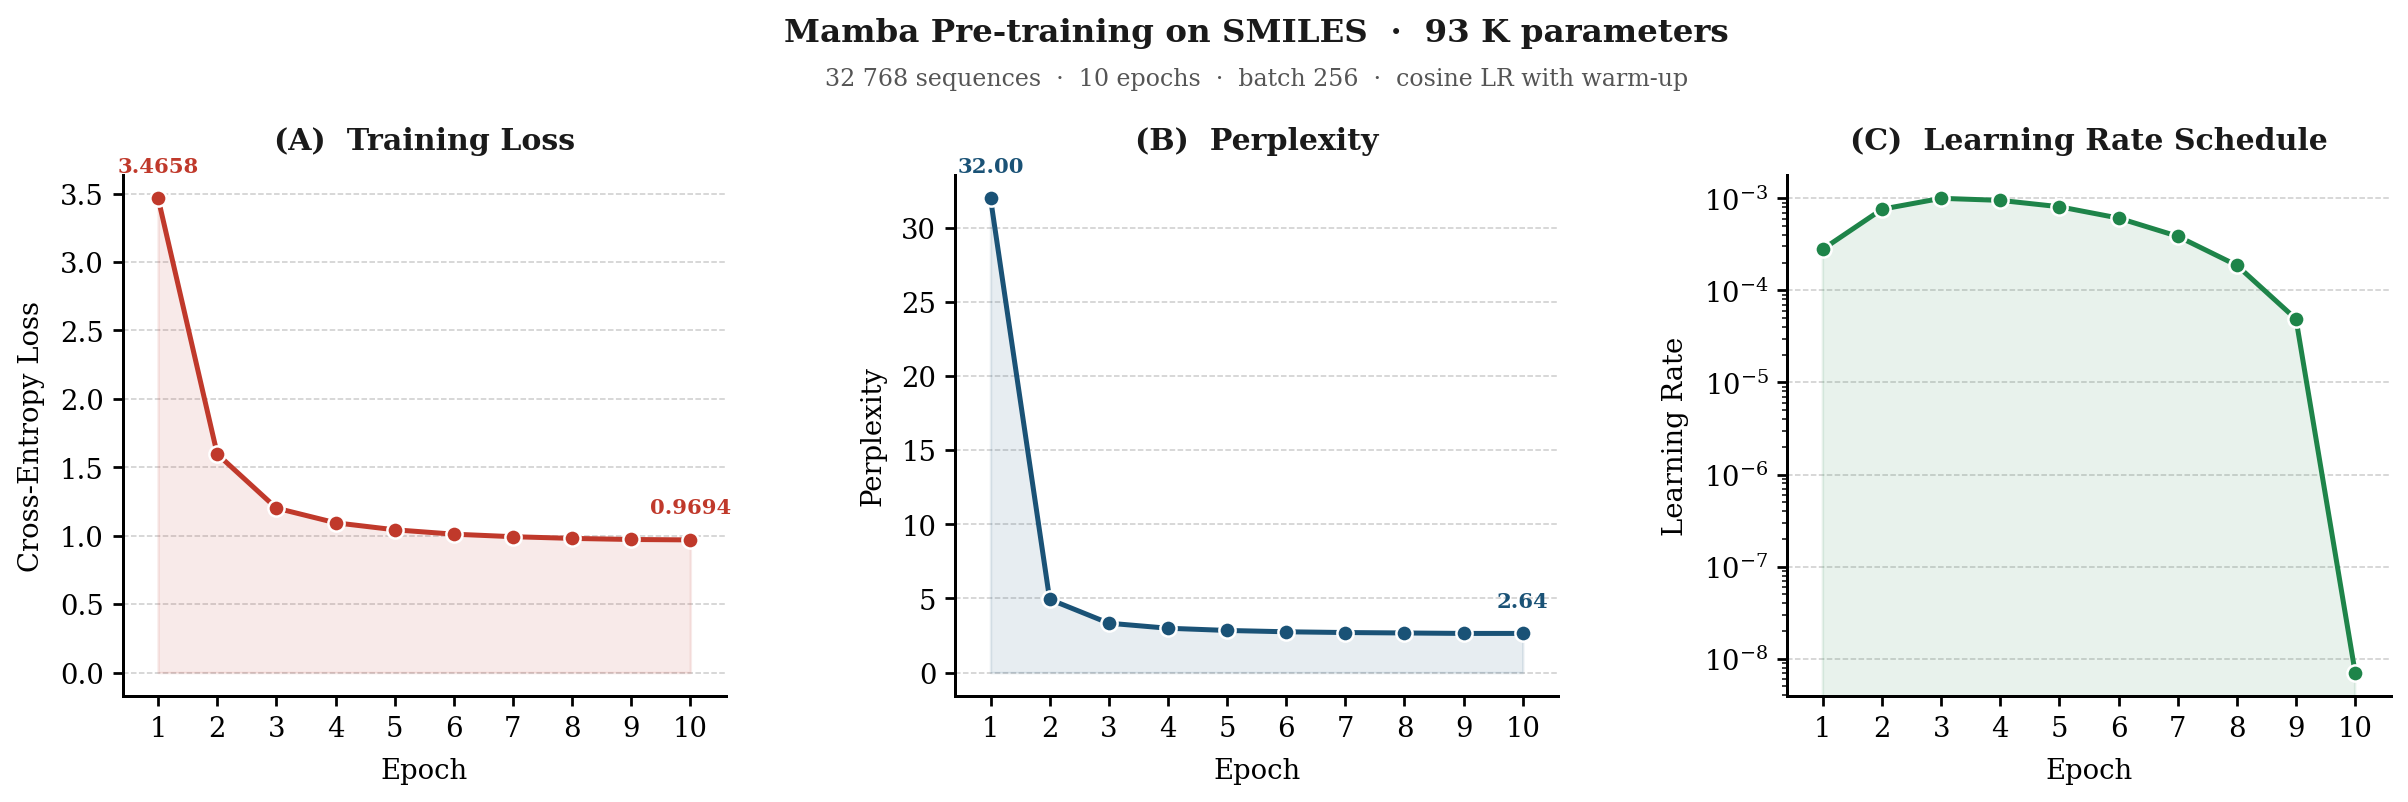

In [ ]:
epochs      = np.arange(1, 11)
loss        = [3.4658, 1.5970, 1.2017, 1.0945, 1.0434, 1.0113, 0.9928, 0.9804, 0.9724, 0.9694]
perplexity  = [32.00,  4.94,   3.33,   2.99,   2.84,   2.75,   2.70,   2.67,   2.64,   2.64]
lr          = [2.81e-04,7.62e-04,1.00e-03,9.50e-04,8.10e-04,
               6.10e-04,3.87e-04,1.87e-04,4.88e-05,7.07e-09]

plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["DejaVu Serif"],
    "font.size":          11,
    "axes.linewidth":     1.2,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "xtick.major.size":   4,
    "ytick.major.size":   4,
    "xtick.major.width":  1.1,
    "ytick.major.width":  1.1,
    "figure.dpi":         180,
})

COLORS = {
    "loss":  "#C0392B",
    "ppl":   "#1A5276",
    "lr":    "#1E8449",
}
ALPHA_FILL = 0.10

fig = plt.figure(figsize=(14, 4.6))
fig.patch.set_facecolor("white")

gs = gridspec.GridSpec(1, 3, figure=fig,
                       left=0.07, right=0.97,
                       top=0.78,  bottom=0.15,
                       wspace=0.38)

axes = [fig.add_subplot(gs[i]) for i in range(3)]

def styled_plot(ax, x, y, color, ylabel, title, logy=False,
                annotate=True, fmt="{:.4f}"):

    ax.set_facecolor("white")
    ax.yaxis.grid(True, linestyle="--", linewidth=0.6,
                  color="#CCCCCC", zorder=0)
    ax.set_axisbelow(True)
    ax.fill_between(x, y, alpha=ALPHA_FILL, color=color, zorder=1)
    ax.plot(x, y, color=color, linewidth=2.0,
            zorder=3, solid_capstyle="round")
    ax.scatter(x, y, color=color, s=42, zorder=4,
               edgecolors="white", linewidths=1.0)
    if annotate:
        for idx in [0, -1]:
            xi, yi = x[idx], y[idx]
            offset = (0, 9) if idx == 0 else (0, 9)
            ax.annotate(
                fmt.format(yi),
                xy=(xi, yi),
                xytext=offset,
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=8.5,
                color=color,
                fontweight="bold",
            )

    if logy:
        ax.set_yscale("log")

    ax.set_xlim(0.4, 10.6)
    ax.set_xticks(x)
    ax.set_xlabel("Epoch", fontsize=11, labelpad=6)
    ax.set_ylabel(ylabel, fontsize=11, labelpad=6)

    ax.set_title(title, fontsize=12, fontweight="bold",
                 pad=10, color="#1a1a1a")

    return ax

# Loss
styled_plot(axes[0], epochs, loss,
            color=COLORS["loss"],
            ylabel="Cross-Entropy Loss",
            title="(A)  Training Loss",
            fmt="{:.4f}")

# Perplexity
styled_plot(axes[1], epochs, perplexity,
            color=COLORS["ppl"],
            ylabel="Perplexity",
            title="(B)  Perplexity",
            fmt="{:.2f}")

# Learning Rate
styled_plot(axes[2], epochs, lr,
            color=COLORS["lr"],
            ylabel="Learning Rate",
            title="(C)  Learning Rate Schedule",
            logy=True, annotate=False)

axes[2].yaxis.set_major_formatter(
    ticker.LogFormatterSciNotation(labelOnlyBase=False))

fig.text(
    0.52, 0.97,
    "Mamba Pre-training on SMILES  ·  93 K parameters",
    ha="center", va="top",
    fontsize=13, fontweight="bold", color="#1a1a1a",
)
fig.text(
    0.52, 0.91,
    "32 768 sequences  ·  10 epochs  ·  batch 256  ·  cosine LR with warm-up",
    ha="center", va="top",
    fontsize=9.5, color="#555555",
)

plt.show()

# Fine-Tune

In [43]:
TASKS_CONFIG = {
    # --- Distribution (Table 2) ---
    'BBB':      {'tdc_name': 'BBB_Martins',       'type': 'classification', 'metric': 'roc-auc'},
    'PPBR':     {'tdc_name': 'PPBR_AZ',           'type': 'regression',     'metric': 'mae'},
    'VD':       {'tdc_name': 'VDss_Lombardo',     'type': 'regression',     'metric': 'mae'},

    # --- Metabolism (Table 3) ---
    'CYP2D6-I': {'tdc_name': 'CYP2D6_Veith',      'type': 'classification', 'metric': 'pr-auc'},
    'CYP3A4-I': {'tdc_name': 'CYP3A4_Veith',      'type': 'classification', 'metric': 'pr-auc'},
    'CYP2C9-I': {'tdc_name': 'CYP2C9_Veith',      'type': 'classification', 'metric': 'pr-auc'},
    
    'CYP2D6-S': {'tdc_name': 'CYP2D6_Substrate_CarbonMangels', 'type': 'classification', 'metric': 'pr-auc'},
    'CYP3A4-S': {'tdc_name': 'CYP3A4_Substrate_CarbonMangels', 'type': 'classification', 'metric': 'roc-auc'},
    'CYP2C9-S': {'tdc_name': 'CYP2C9_Substrate_CarbonMangels', 'type': 'classification', 'metric': 'pr-auc'},

    # --- Pharmacokinetics ---
    'Half-Life':{'tdc_name': 'Half_Life_Obach',        'type': 'regression', 'metric': 'spearman'},
    'CL-Micro': {'tdc_name': 'Clearance_Microsome_AZ', 'type': 'regression', 'metric': 'spearman'},
    'CL-Hepa':  {'tdc_name': 'Clearance_Hepatocyte_AZ','type': 'regression', 'metric': 'spearman'},

    # --- Toxicity (Table 4 & 1) ---
    'hERG':     {'tdc_name': 'hERG',         'type': 'classification', 'metric': 'roc-auc'},
    'AMES':     {'tdc_name': 'AMES',         'type': 'classification', 'metric': 'roc-auc'},
    'DILI':     {'tdc_name': 'DILI',         'type': 'classification', 'metric': 'roc-auc'},
    'LD50':     {'tdc_name': 'LD50_Zhu',     'type': 'regression',     'metric': 'mae'},
    
    # --- Absorption (Table 1) ---
    'Caco2':    {'tdc_name': 'Caco2_Wang',   'type': 'regression',     'metric': 'mae'},
    'HIA':      {'tdc_name': 'HIA_Hou',      'type': 'classification', 'metric': 'roc-auc'},
    'Pgp':      {'tdc_name': 'Pgp_Broccatelli','type': 'classification', 'metric': 'roc-auc'},
    'Bioav':    {'tdc_name': 'Bioavailability_Ma','type': 'classification', 'metric': 'roc-auc'},
    'Lipo':     {'tdc_name': 'Lipophilicity_AstraZeneca', 'type': 'regression', 'metric': 'mae'},
    'AqSol':    {'tdc_name': 'Solubility_AqSolDB', 'type': 'regression', 'metric': 'mae'},
}

CFG = {
    'device': "cpu",
    'data_path': './data/raw',
    'training': {'learning_rate': 1e-3, 'epochs': 10},
    'mamba_pretrained_path': '/Users/ablagodarniy/Desktop/exp/mamba_vocab.pt',
    'mamba_vocab_path': '/Users/ablagodarniy/Desktop/exp/mamba_vocab.pt', 
    'max_seq_len': 128
}

In [44]:
def get_data(cfg_entry):
    name = cfg_entry['tdc_name']
    try:
        data = ADME(name=name, path=CFG['data_path'])
    except:
        data = Tox(name=name, path=CFG['data_path'])
        
    s = data.get_split(method='scaffold', seed=42, frac=[0.8, 0.1, 0.1])
    return s['train'], s['valid'], s['test']

def get_dataloader(dataset, batch_size=32, shuffle=True):
    if len(dataset) == 0:
        raise ValueError("Датасет пуст!")
        
    sample = dataset[0]
    x_sample = sample[0]
    
    if HAS_PYG and isinstance(x_sample, Data):
        return PyGDataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

    return TorchDataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [45]:
class UniversalTrainer:
    def __init__(self, model, params, task_config, device):
        self.model = model.to(device)
        self.task_type = task_config['type']
        self.metric_name = task_config['metric']
        self.device = device
        self.optimizer = optim.AdamW(model.parameters(), lr=params['learning_rate'])
        self.criterion = nn.BCEWithLogitsLoss() if self.task_type == 'classification' else nn.L1Loss()

    def run(self, train, val, test, epochs):
        train_l = get_dataloader(train, 32, True)
        val_l = get_dataloader(val, 32, False)
        test_l = get_dataloader(test, 32, False)
        
        higher_is_better = self.metric_name in ['roc-auc', 'pr-auc', 'spearman']
        best_score = -float('inf') if higher_is_better else float('inf')
        best_state = None

        for epoch in range(epochs):
            self.model.train()
            for batch in tqdm(train_l, desc=f"Ep {epoch+1}", leave=False):
                self.optimizer.zero_grad()
                if isinstance(batch, list): x, y = batch[0].to(self.device), batch[1].to(self.device)
                else: x, y = batch.to(self.device), batch.y.to(self.device)
                
                pred = self.model(x)
                if y.shape!=pred.shape: y=y.view_as(pred)
                loss = self.criterion(pred, y)
                loss.backward()
                self.optimizer.step()
            val_score = self.evaluate(val_l)
            improved = (val_score > best_score) if higher_is_better else (val_score < best_score)
            if improved:
                best_score = val_score
                best_state = self.model.state_dict()
        if best_state: self.model.load_state_dict(best_state)
        return self.evaluate(test_l)

    def evaluate(self, loader):
        self.model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for batch in loader:
                if isinstance(batch, (list, tuple)): 
                    x, y = batch[0].to(self.device), batch[1].to(self.device)
                else: 
                    x, y = batch.to(self.device), batch.y.to(self.device)
                out = self.model(x)
                preds.extend(out.cpu().numpy())
                targets.extend(y.cpu().numpy())
        
        preds = np.array(preds).flatten()
        targets = np.array(targets).flatten()
        
        if np.isnan(preds).any(): preds = np.nan_to_num(preds)

        if self.metric_name == 'roc-auc':
            try:
                probs = 1 / (1 + np.exp(-preds))
                if len(np.unique(targets)) < 2: return 0.5
                return roc_auc_score(targets, probs)
            except: return 0.5
        elif self.metric_name == 'pr-auc':
            try:
                probs = 1 / (1 + np.exp(-preds))
                return average_precision_score(targets, probs)
            except: return 0.0
        elif self.metric_name == 'mae':
            return mean_absolute_error(targets, preds)
        elif self.metric_name == 'spearman':
            val, _ = spearmanr(targets, preds)
            return 0.0 if np.isnan(val) else val
        return 0.0


In [46]:
class ModelFactory:
    @staticmethod
    def create_model(model_name, config, device, pretrained_path, tokenizer=None):
        if model_name == 'morgan_mlp':
            input_dim = config['featurization']['morgan_nbits']
            model = MorganMLP(input_dim=input_dim)
            return model, 'morgan'

        elif model_name == 'cnn':
            if tokenizer is None:
                raise ValueError("Tokenizer required for CNN initialization")
            
            vocab_size = len(tokenizer.vocab)
            model = SmilesCNN(
                vocab_size=vocab_size,
                embed_dim=64,
                max_len=config['featurization']['max_seq_len']
            )
            return model, 'seq'

        elif model_name == 'gcn':
            model = GCN(
                node_features=6, 
                hidden_dim=config['model_params']['gnn_hidden_dim']
            )
            return model, 'graph'

        elif model_name == 'neural_fp':
            base_gcn = GCN(node_features=6, hidden_dim=config['model_params']['gnn_hidden_dim'])
            
            model = NeuralFP(pretrained_gcn=base_gcn)
            return model, 'graph'
        
        elif model_name == 'mamba':
            if tokenizer is None:
                raise ValueError("Tokenizer required for Mamba")
            
            vocab_size = len(tokenizer.vocab)
            backbone = Mamba3Backbone(vocab_size=vocab_size, d_model=128, n_layers=4)
            
            if pretrained_path and os.path.exists(pretrained_path):
                backbone.load_state_dict(torch.load(pretrained_path, map_location=device))
                
            model = Mamba3ForADMET(backbone=backbone, n_classes=1)
            return model, 'seq'
        else:
            raise ValueError(f"Unknown model name: {model_name}")

In [47]:
def create_mamba_vocab():
    zinc_data = MolGen(name='ZINC', path='./data/raw')
    all_smiles = zinc_data.get_split()['train']['smiles'].tolist()
    for n in [50000, 100000, 150000, 200000]:
        tokenizer = SMILESTokenizer(max_len=128)
        tokenizer.train(all_smiles[:n])
        current_size = len(tokenizer.vocab)
        if current_size == 62:
            vocab_path = CFG['mamba_vocab_path']
            tokenizer.save_vocab(vocab_path)
            print(f"Словарь создан! Размер: {len(tokenizer.vocab)}") # 62
            return
        elif current_size > 62:
            return

create_mamba_vocab()

Found local copy...
Loading...
Done!
2026-04-19 12:55:22,169 - INFO - Tokenizer trained. Vocab size: 57
2026-04-19 12:55:22,545 - INFO - Tokenizer trained. Vocab size: 59
2026-04-19 12:55:23,121 - INFO - Tokenizer trained. Vocab size: 62


Словарь создан! Размер: 62


In [ ]:
def main():
    device = torch.device(CFG['device'])

    tok_char = CharTokenizer()
    morgan = MorganFeaturizer()
    graph = GraphFeaturizer()
    tok_mamba = SMILESTokenizer(max_len=CFG['max_seq_len'])
    if os.path.exists(CFG['mamba_vocab_path']):
        tok_mamba.load_vocab(CFG['mamba_vocab_path'])
        print(f"Словарь Mamba загружен! Размер: {len(tok_mamba.vocab)}")
    else:
        print(f"ОШИБКА: Файл {CFG['mamba_vocab_path']} не найден!")

    models = ['morgan_mlp', 'cnn', 'gcn', 'neural_fp', 'mamba'] 
    target_tasks = list(TASKS_CONFIG.keys())
    
    all_results = {}
    print(f"Tasks scheduled: {target_tasks}")

    for task in target_tasks:
        t_cfg = TASKS_CONFIG[task]
        metric_display = t_cfg['metric'].upper()
        all_results[task] = {}
        try:
            train, val, test = get_data(t_cfg)
        except Exception as e:
            print(e)

        for m_name in models:
            if m_name == 'morgan_mlp':
                feat = morgan 
                model = MorganMLP(input_dim=1024)
                
            elif m_name == 'cnn':
                feat = lambda x: tok_char.encode(x)
                model = SmilesCNN(vocab_size=len(tok_char.vocab), embed_dim=64, max_len=128)
                
            elif m_name in ['gcn', 'neural_fp']:
                if not HAS_PYG: 
                    all_results[task][m_name] = None
                    continue
                feat = graph
                base = GCN(node_features=9, hidden_dim=128)
                model = base if m_name == 'gcn' else NeuralFP(pretrained_gcn=base)
                
            elif m_name == 'mamba':
                            feat = lambda x: tok_mamba.encode(x)
                            vocab_size = len(tok_mamba.vocab)
                            
                            backbone = Mamba3Backbone(
                                vocab_size=vocab_size, 
                                d_model=64,
                                n_layers=2
                            )
                            
                            if os.path.exists(CFG['mamba_pretrained_path']):
                                backbone = Mamba3Backbone(vocab_size=len(tok_mamba.vocab), d_model=64, n_layers=2)
                                state_dict = torch.load('mamba_backbone.pth', map_location=device)
                                backbone.load_state_dict(state_dict)
                                print(f"Успешно загружены веса Mamba из {CFG['mamba_pretrained_path']}")
                            else:
                                print("Претрейн веса Mamba не найдены! Обучение с нуля.")
                            
                            model = Mamba3ForADMET(backbone=backbone, n_classes=1)

            tr_ds = MolecularDataset(train['Drug'].tolist(), train['Y'].tolist(), feat)
            va_ds = MolecularDataset(val['Drug'].tolist(), val['Y'].tolist(), feat)
            te_ds = MolecularDataset(test['Drug'].tolist(), test['Y'].tolist(), feat)
            
            trainer = UniversalTrainer(model, CFG['training'], t_cfg, device)
            final_metric = trainer.run(tr_ds, va_ds, te_ds, CFG['training']['epochs'])
            
            all_results[task][m_name] = final_metric
            logger.info(f">>> {task} | {m_name} Test {metric_display}: {final_metric:.4f}")

    print("FINAL RESULTS SUMMARY (Best Test Metrics)")
    print()
    
    header = f"{'Task':<15} | {'Metric':<9} | " + " | ".join([f"{m:>10}" for m in models])
    print(header)
    print("-" * len(header))
    
    for task in target_tasks:
        if task not in all_results: continue
        
        metric_name = TASKS_CONFIG[task]['metric'].upper()
        row_str = f"{task:<15} | {metric_name:<9} | "
        
        for m in models:
            val_metric = all_results[task].get(m, None)
            if val_metric is None:
                val_str = "   N/A    "
            else:
                val_str = f"{val_metric:10.4f}"
            row_str += f"{val_str} | "
        print(row_str)
        
    print("="*95)

In [64]:
import json
from pathlib import Path

path = Path('experiment.ipynb')
nb = json.loads(path.read_text())

RESULTS_DIR = os.path.join(DATA_DIR, "results")
FINE_TUNE_RESULTS_PATH = os.path.join(RESULTS_DIR, "fine_tune_results.json")

CFG = {
    'device': "cpu",
    'data_path': './data/raw',
    'training': {
        'learning_rate': 1e-3,
        'epochs': 10,
        'batch_size': 32,
    },
    'mamba_pretrained_path': 'mamba_backbone.pth',
    'mamba_vocab_path': 'mamba_vocab.pt',
    'max_seq_len': 128,
    'results_path': FINE_TUNE_RESULTS_PATH,
}


def ensure_results_dir():
    os.makedirs(RESULTS_DIR, exist_ok=True)


def _to_serializable(value):
    if isinstance(value, dict):
        return {str(k): _to_serializable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_to_serializable(v) for v in value]
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().tolist()
    return value


def load_results_cache(path=FINE_TUNE_RESULTS_PATH):
    if not os.path.exists(path):
        return {
            'meta': {
                'schema_version': 1,
                'created_at': pd.Timestamp.utcnow().isoformat(),
                'updated_at': None,
            },
            'runs': {},
        }

    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def save_results_cache(cache, path=FINE_TUNE_RESULTS_PATH):
    ensure_results_dir()
    cache.setdefault('meta', {})
    cache['meta']['schema_version'] = 1
    cache['meta']['updated_at'] = pd.Timestamp.utcnow().isoformat()
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(_to_serializable(cache), f, ensure_ascii=False, indent=2)


def build_run_key(task_name, model_name):
    return f"{task_name}::{model_name}"


def get_cached_run(cache, task_name, model_name):
    return cache.get('runs', {}).get(build_run_key(task_name, model_name))


def upsert_cached_run(cache, task_name, model_name, payload):
    cache.setdefault('runs', {})
    cache['runs'][build_run_key(task_name, model_name)] = _to_serializable(payload)


def extract_summary_results(cache, tasks=None, models=None):
    summary = {}
    for run_key, run_data in cache.get('runs', {}).items():
        task_name, model_name = run_key.split('::', 1)
        if tasks is not None and task_name not in tasks:
            continue
        if models is not None and model_name not in models:
            continue
        summary.setdefault(task_name, {})[model_name] = run_data.get('test_metric')
    return summary


def build_results_table(all_results, tasks_config, models):
    rows = []
    for task_name, model_scores in all_results.items():
        row = {
            'task': task_name,
            'metric': tasks_config[task_name]['metric'].upper(),
        }
        for model_name in models:
            row[model_name] = model_scores.get(model_name)
        rows.append(row)
    return pd.DataFrame(rows)


def print_results_table(results_df, models):
    print("=" * 93)
    print("FINAL RESULTS SUMMARY (Best Test Metrics)")
    print("=" * 93)
    if results_df.empty:
        print("No results available")
        print("=" * 93)
        return

    header = f"{'Task':<15} | {'Metric':<9} | " + " | ".join([f"{m:>10}" for m in models])
    print(header)
    print("-" * len(header))

    for _, row in results_df.iterrows():
        row_str = f"{row['task']:<15} | {row['metric']:<9} | "
        for model_name in models:
            value = row.get(model_name)
            value_str = "   N/A    " if pd.isna(value) else f"{float(value):10.4f}"
            row_str += f"{value_str} | "
        print(row_str)
    print("=" * 93)

In [65]:
def compute_financial_results(results_df):
    if results_df.empty:
        return pd.DataFrame(columns=['model', 'wins', 'avg_score', 'avg_rank'])

    metric_direction = {
        'ROC-AUC': True,
        'PR-AUC': True,
        'SPEARMAN': True,
        'MAE': False,
    }

    score_columns = [c for c in results_df.columns if c not in ['task', 'metric']]
    wins = {model_name: 0 for model_name in score_columns}
    avg_scores = {model_name: [] for model_name in score_columns}
    avg_ranks = {model_name: [] for model_name in score_columns}

    for _, row in results_df.iterrows():
        metric_name = row['metric']
        higher_is_better = metric_direction.get(metric_name, True)
        available_scores = {
            model_name: float(row[model_name])
            for model_name in score_columns
            if pd.notna(row[model_name])
        }
        if not available_scores:
            continue

        best_value = max(available_scores.values()) if higher_is_better else min(available_scores.values())
        for model_name, score in available_scores.items():
            avg_scores[model_name].append(score)
            if score == best_value:
                wins[model_name] += 1

        ordered = sorted(
            available_scores.items(),
            key=lambda item: item[1],
            reverse=higher_is_better,
        )
        for rank, (model_name, _) in enumerate(ordered, start=1):
            avg_ranks[model_name].append(rank)

    financial_rows = []
    for model_name in score_columns:
        financial_rows.append({
            'model': model_name,
            'wins': wins[model_name],
            'avg_score': float(np.mean(avg_scores[model_name])) if avg_scores[model_name] else np.nan,
            'avg_rank': float(np.mean(avg_ranks[model_name])) if avg_ranks[model_name] else np.nan,
        })

    return pd.DataFrame(financial_rows).sort_values(['wins', 'avg_rank'], ascending=[False, True]).reset_index(drop=True)


def plot_financial_results(results_df, financial_df):
    if results_df.empty:
        print("No fine-tune results to visualize")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    heatmap_df = results_df.set_index('task')[[c for c in results_df.columns if c not in ['metric'] and c != 'task']]
    im = axes[0].imshow(heatmap_df.fillna(np.nan).values, aspect='auto', cmap='viridis')
    axes[0].set_title('Fine-tune metrics by task/model')
    axes[0].set_xticks(range(len(heatmap_df.columns)))
    axes[0].set_xticklabels(heatmap_df.columns, rotation=45, ha='right')
    axes[0].set_yticks(range(len(heatmap_df.index)))
    axes[0].set_yticklabels(heatmap_df.index)
    plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    axes[1].axis('off')
    table_df = financial_df.copy()
    if not table_df.empty:
        for col in ['avg_score', 'avg_rank']:
            table_df[col] = table_df[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else 'N/A')
        table = axes[1].table(
            cellText=table_df.values,
            colLabels=table_df.columns,
            loc='center'
        )
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 1.5)
    axes[1].set_title('Financial summary')

    plt.tight_layout()
    plt.show()

In [66]:
class UniversalTrainer:
    def __init__(self, model, params, task_config, device):
        self.model = model.to(device)
        self.task_type = task_config['type']
        self.metric_name = task_config['metric']
        self.device = device
        self.learning_rate = params['learning_rate']
        self.batch_size = params.get('batch_size', 32)
        self.optimizer = optim.AdamW(model.parameters(), lr=self.learning_rate)
        self.criterion = nn.BCEWithLogitsLoss() if self.task_type == 'classification' else nn.L1Loss()

    def run(self, train, val, test, epochs):
        train_l = get_dataloader(train, self.batch_size, True)
        val_l = get_dataloader(val, self.batch_size, False)
        test_l = get_dataloader(test, self.batch_size, False)

        higher_is_better = self.metric_name in ['roc-auc', 'pr-auc', 'spearman']
        best_score = -float('inf') if higher_is_better else float('inf')
        best_state = None
        history = []
        train_start_time = pd.Timestamp.utcnow()
        train_start_perf = pd.Timestamp.now().timestamp()

        for epoch in range(epochs):
            epoch_start_perf = pd.Timestamp.now().timestamp()
            self.model.train()
            epoch_loss_sum = 0.0
            epoch_batches = 0

            for batch in tqdm(train_l, desc=f"Ep {epoch+1}", leave=False):
                self.optimizer.zero_grad()
                if isinstance(batch, (list, tuple)):
                    x, y = batch[0].to(self.device), batch[1].to(self.device)
                else:
                    x, y = batch.to(self.device), batch.y.to(self.device)

                pred = self.model(x)
                if y.shape != pred.shape:
                    y = y.view_as(pred)
                loss = self.criterion(pred, y)
                loss.backward()
                self.optimizer.step()

                epoch_loss_sum += float(loss.item())
                epoch_batches += 1

            train_loss = epoch_loss_sum / max(epoch_batches, 1)
            val_score = self.evaluate(val_l)
            improved = (val_score > best_score) if higher_is_better else (val_score < best_score)
            if improved:
                best_score = val_score
                best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}

            history.append({
                'epoch': epoch + 1,
                'train_loss': train_loss,
                'val_metric': float(val_score),
                'learning_rate': float(self.optimizer.param_groups[0]['lr']),
                'epoch_duration_sec': float(pd.Timestamp.now().timestamp() - epoch_start_perf),
                'best_val_metric_so_far': float(best_score),
            })

        if best_state:
            self.model.load_state_dict(best_state)
        test_score = self.evaluate(test_l)
        total_duration_sec = float(pd.Timestamp.now().timestamp() - train_start_perf)

        return {
            'test_metric': float(test_score),
            'best_val_metric': float(best_score),
            'history': history,
            'training_time_sec': total_duration_sec,
            'training_started_at': train_start_time.isoformat(),
            'training_finished_at': pd.Timestamp.utcnow().isoformat(),
            'epochs': epochs,
            'batch_size': self.batch_size,
            'learning_rate': float(self.learning_rate),
        }

    def evaluate(self, loader):
        self.model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for batch in loader:
                if isinstance(batch, (list, tuple)):
                    x, y = batch[0].to(self.device), batch[1].to(self.device)
                else:
                    x, y = batch.to(self.device), batch.y.to(self.device)
                out = self.model(x)
                preds.extend(out.cpu().numpy())
                targets.extend(y.cpu().numpy())

        preds = np.array(preds).flatten()
        targets = np.array(targets).flatten()

        if np.isnan(preds).any():
            preds = np.nan_to_num(preds)

        if self.metric_name == 'roc-auc':
            try:
                probs = 1 / (1 + np.exp(-preds))
                if len(np.unique(targets)) < 2:
                    return 0.5
                return roc_auc_score(targets, probs)
            except:
                return 0.5
        elif self.metric_name == 'pr-auc':
            try:
                probs = 1 / (1 + np.exp(-preds))
                return average_precision_score(targets, probs)
            except:
                return 0.0
        elif self.metric_name == 'mae':
            return mean_absolute_error(targets, preds)
        elif self.metric_name == 'spearman':
            val, _ = spearmanr(targets, preds)
            return 0.0 if np.isnan(val) else val
        return 0.0

In [67]:
def main(force_recompute=False, selected_tasks=None, selected_models=None):
    device = torch.device(CFG['device'])
    cache = load_results_cache(CFG['results_path'])

    tok_char = CharTokenizer()
    morgan = MorganFeaturizer()
    graph = GraphFeaturizer()
    tok_mamba = SMILESTokenizer(max_len=CFG['max_seq_len'])
    if os.path.exists(CFG['mamba_vocab_path']):
        tok_mamba.load_vocab(CFG['mamba_vocab_path'])
        print(f"Словарь Mamba загружен! Размер: {len(tok_mamba.vocab)}")
    else:
        print(f"ОШИБКА: Файл {CFG['mamba_vocab_path']} не найден!")

    models = selected_models or ['morgan_mlp', 'cnn', 'gcn', 'neural_fp', 'mamba']
    target_tasks = selected_tasks or list(TASKS_CONFIG.keys())

    print(f"Tasks scheduled: {target_tasks}")

    for task in target_tasks:
        t_cfg = TASKS_CONFIG[task]
        metric_display = t_cfg['metric'].upper()
        try:
            train, val, test = get_data(t_cfg)
        except Exception as e:
            logger.exception(f"Failed to load data for {task}: {e}")
            continue

        for m_name in models:
            cached_run = get_cached_run(cache, task, m_name)
            if cached_run and not force_recompute:
                logger.info(f"Using cached fine-tune result for {task} | {m_name}")
                continue

            if m_name == 'morgan_mlp':
                feat = morgan
                model = MorganMLP(input_dim=1024)
            elif m_name == 'cnn':
                feat = lambda x: tok_char.encode(x)
                model = SmilesCNN(vocab_size=len(tok_char.vocab), embed_dim=64, max_len=128)
            elif m_name in ['gcn', 'neural_fp']:
                if not HAS_PYG:
                    upsert_cached_run(cache, task, m_name, {
                        'task': task,
                        'model': m_name,
                        'metric_name': metric_display,
                        'status': 'skipped',
                        'reason': 'torch_geometric is not available',
                        'test_metric': None,
                    })
                    save_results_cache(cache, CFG['results_path'])
                    continue
                feat = graph
                base = GCN(node_features=9, hidden_dim=128)
                model = base if m_name == 'gcn' else NeuralFP(pretrained_gcn=base)
            elif m_name == 'mamba':
                feat = lambda x: tok_mamba.encode(x)
                vocab_size = len(tok_mamba.vocab)
                backbone = Mamba3Backbone(vocab_size=vocab_size, d_model=64, n_layers=2)
                if os.path.exists(CFG['mamba_pretrained_path']):
                    state_dict = torch.load(CFG['mamba_pretrained_path'], map_location=device)
                    backbone.load_state_dict(state_dict)
                    print(f"Успешно загружены веса Mamba из {CFG['mamba_pretrained_path']}")
                else:
                    print("Претрейн веса Mamba не найдены! Обучение с нуля.")
                model = Mamba3ForADMET(backbone=backbone, n_classes=1)
            else:
                raise ValueError(f"Unknown model: {m_name}")

            tr_ds = MolecularDataset(train['Drug'].tolist(), train['Y'].tolist(), feat)
            va_ds = MolecularDataset(val['Drug'].tolist(), val['Y'].tolist(), feat)
            te_ds = MolecularDataset(test['Drug'].tolist(), test['Y'].tolist(), feat)

            trainer = UniversalTrainer(model, CFG['training'], t_cfg, device)
            run_result = trainer.run(tr_ds, va_ds, te_ds, CFG['training']['epochs'])
            run_payload = {
                'task': task,
                'model': m_name,
                'metric_name': metric_display,
                'task_type': t_cfg['type'],
                'status': 'completed',
                'test_metric': run_result['test_metric'],
                'best_val_metric': run_result['best_val_metric'],
                'history': run_result['history'],
                'training_time_sec': run_result['training_time_sec'],
                'training_started_at': run_result['training_started_at'],
                'training_finished_at': run_result['training_finished_at'],
                'epochs': run_result['epochs'],
                'batch_size': run_result['batch_size'],
                'learning_rate': run_result['learning_rate'],
                'dataset_sizes': {
                    'train': len(tr_ds),
                    'val': len(va_ds),
                    'test': len(te_ds),
                },
            }
            upsert_cached_run(cache, task, m_name, run_payload)
            save_results_cache(cache, CFG['results_path'])
            logger.info(f">>> {task} | {m_name} Test {metric_display}: {run_result['test_metric']:.4f}")

    all_results = extract_summary_results(cache, tasks=target_tasks, models=models)
    results_df = build_results_table(all_results, TASKS_CONFIG, models)
    print_results_table(results_df, models)
    financial_df = compute_financial_results(results_df)
    return results_df, financial_df, cache

In [68]:
LENGTH_TASKS_CONFIG = len(TASKS_CONFIG.keys())
tasks = list(TASKS_CONFIG.keys())[LENGTH_TASKS_CONFIG // 2:]
len(tasks)

11

Downloading...


Словарь Mamba загружен! Размер: 62
Tasks scheduled: ['CL-Hepa', 'hERG', 'AMES', 'DILI', 'LD50', 'Caco2', 'HIA', 'Pgp', 'Bioav', 'Lipo', 'AqSol']


100%|██████████| 91.6k/91.6k [00:00<00:00, 310kiB/s]
Loading...
Done!
100%|██████████| 1213/1213 [00:00<00:00, 1805.62it/s]
2026-04-19 13:58:55,253 - INFO - >>> CL-Hepa | morgan_mlp Test SPEARMAN: 0.3379
2026-04-19 13:58:59,235 - INFO - >>> CL-Hepa | cnn Test SPEARMAN: 0.2576
2026-04-19 13:59:09,757 - INFO - >>> CL-Hepa | gcn Test SPEARMAN: 0.0109
2026-04-19 13:59:20,383 - INFO - >>> CL-Hepa | neural_fp Test SPEARMAN: -0.0191


Успешно загружены веса Mamba из mamba_backbone.pth


2026-04-19 14:02:43,652 - INFO - >>> CL-Hepa | mamba Test SPEARMAN: 0.1837
['lipophilicity_astrazeneca', 'solubility_aqsoldb', 'hydrationfreeenergy_freesolv', 'caco2_wang', 'pampa_ncats', 'approved_pampa_ncats', 'hia_hou', 'pgp_broccatelli', 'bioavailability_ma', 'vdss_lombardo', 'cyp2c19_veith', 'cyp2d6_veith', 'cyp3a4_veith', 'cyp1a2_veith', 'cyp2c9_veith', 'cyp2c9_substrate_carbonmangels', 'cyp2d6_substrate_carbonmangels', 'cyp3a4_substrate_carbonmangels', 'bbb_martins', 'b3db_classification', 'b3db_regression', 'ppbr_az', 'half_life_obach', 'clearance_hepatocyte_az', 'clearance_microsome_az', 'hlm', 'rlm']
Downloading...
100%|██████████| 50.2k/50.2k [00:00<00:00, 300kiB/s]
Loading...
Done!
100%|██████████| 655/655 [00:00<00:00, 2021.63it/s]
2026-04-19 14:02:50,798 - INFO - >>> hERG | morgan_mlp Test ROC-AUC: 0.8094
2026-04-19 14:02:52,913 - INFO - >>> hERG | cnn Test ROC-AUC: 0.6631
2026-04-19 14:02:58,438 - INFO - >>> hERG | gcn Test ROC-AUC: 0.6313
2026-04-19 14:03:03,677 - INFO 

...

Успешно загружены веса Mamba из mamba_backbone.pth


2026-04-19 15:17:05,950 - INFO - >>> Lipo | mamba Test MAE: 0.7310
Found local copy...
Loading...
Done!
100%|██████████| 9982/9982 [00:03<00:00, 3212.50it/s]
2026-04-19 15:18:06,299 - INFO - >>> AqSol | morgan_mlp Test MAE: 1.2132
2026-04-19 15:18:39,607 - INFO - >>> AqSol | cnn Test MAE: 0.9899
2026-04-19 15:19:41,428 - INFO - >>> AqSol | gcn Test MAE: 1.3430
2026-04-19 15:20:41,185 - INFO - >>> AqSol | neural_fp Test MAE: 1.2948


Успешно загружены веса Mamba из mamba_backbone.pth


2026-04-19 15:50:29,730 - INFO - >>> AqSol | mamba Test MAE: 0.9048


FINAL RESULTS SUMMARY (Best Test Metrics)
Task            | Metric    | morgan_mlp |        cnn |        gcn |  neural_fp |      mamba
--------------------------------------------------------------------------------------------
CL-Hepa         | SPEARMAN  |     0.3379 |     0.2576 |     0.0109 |    -0.0191 |     0.1837 | 
hERG            | ROC-AUC   |     0.8094 |     0.6631 |     0.6313 |     0.6188 |     0.7181 | 
AMES            | ROC-AUC   |     0.7851 |     0.8033 |     0.7309 |     0.6192 |     0.8084 | 
DILI            | ROC-AUC   |     0.7934 |     0.8420 |     0.7778 |     0.6406 |     0.9045 | 
LD50            | MAE       |     0.5505 |     0.5764 |     0.7691 |     0.7076 |     0.5247 | 
Caco2           | MAE       |     0.4620 |     0.4269 |     1.0673 |     1.0135 |     0.4665 | 
HIA             | ROC-AUC   |     0.7970 |     0.8333 |     0.7091 |     0.6530 |     0.9152 | 
Pgp             | ROC-AUC   |     0.9174 |     0.8483 |     0.7385 |     0.8022 |     0.8843 | 
Bioa

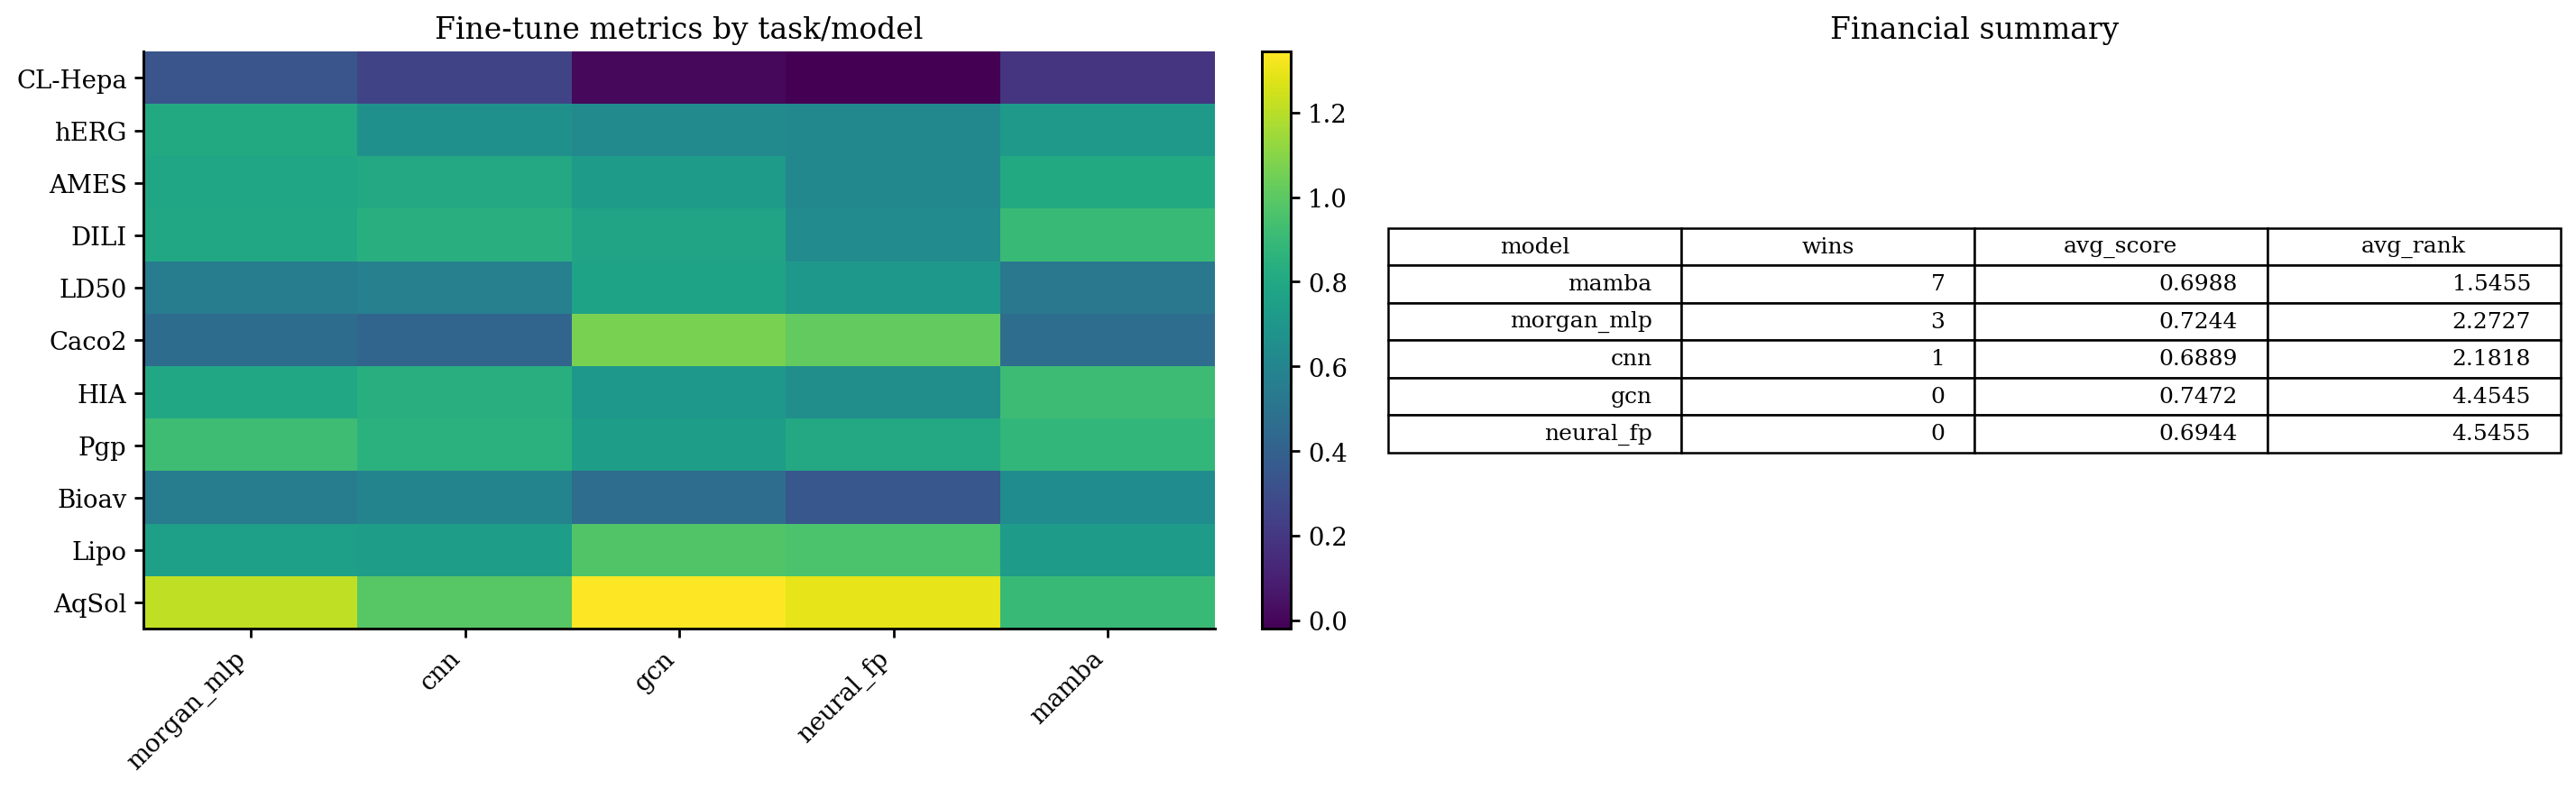

In [69]:
results_df, financial_df, fine_tune_cache = main(selected_tasks=tasks)
plot_financial_results(results_df, financial_df)

In [70]:
def _safe_scaffold_split_frame(df, seed=42, frac=(0.8, 0.1, 0.1), entity='Drug'):
    df = df.copy()
    df = df[df[entity].notna()].reset_index(drop=True)

    valid_rows = []
    dropped = 0
    for _, row in df.iterrows():
        smiles = row[entity]
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            dropped += 1
            continue
        try:
            Chem.MolToSmiles(mol)
            valid_rows.append(row.to_dict())
        except Exception:
            dropped += 1

    clean_df = pd.DataFrame(valid_rows)
    if clean_df.empty:
        raise ValueError('No valid molecules left after RDKit sanitization')

    if dropped:
        logger.warning(f'Dropped {dropped} invalid molecules before scaffold split')

    rng = np.random.RandomState(seed)
    indices = np.arange(len(clean_df))
    rng.shuffle(indices)

    n_total = len(indices)
    n_train = int(n_total * frac[0])
    n_valid = int(n_total * frac[1])

    train_idx = indices[:n_train]
    valid_idx = indices[n_train:n_train + n_valid]
    test_idx = indices[n_train + n_valid:]

    train_df = clean_df.iloc[train_idx].reset_index(drop=True)
    valid_df = clean_df.iloc[valid_idx].reset_index(drop=True)
    test_df = clean_df.iloc[test_idx].reset_index(drop=True)
    return train_df, valid_df, test_df


def get_data(cfg_entry):
    name = cfg_entry['tdc_name']
    try:
        data = ADME(name=name, path=CFG['data_path'])
    except:
        data = Tox(name=name, path=CFG['data_path'])

    try:
        s = data.get_split(method='scaffold', seed=42, frac=[0.8, 0.1, 0.1])
        return s['train'], s['valid'], s['test']
    except Exception as exc:
        logger.warning(f"Scaffold split failed for {name}: {exc}. Falling back to safe random split.")
        df = data.get_data()
        train_df, valid_df, test_df = _safe_scaffold_split_frame(df, seed=42, frac=(0.8, 0.1, 0.1), entity='Drug')
        return train_df, valid_df, test_df

def get_dataloader(dataset, batch_size=32, shuffle=True):
    if len(dataset) == 0:
        raise ValueError("Датасет пуст!")
        
    sample = dataset[0]
    x_sample = sample[0]
    
    if HAS_PYG and isinstance(x_sample, Data):
        return PyGDataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

    return TorchDataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

Found local copy...
Loading...
Done!


Словарь Mamba загружен! Размер: 62
Tasks scheduled: ['CYP2D6-I', 'CYP3A4-I', 'CYP2C9-I']


100%|██████████| 13130/13130 [00:06<00:00, 1982.82it/s]
2026-04-19 16:05:16,682 - INFO - Using cached fine-tune result for CYP2D6-I | morgan_mlp
2026-04-19 16:05:16,682 - INFO - Using cached fine-tune result for CYP2D6-I | cnn
2026-04-19 16:05:16,683 - INFO - Using cached fine-tune result for CYP2D6-I | gcn
2026-04-19 16:05:16,683 - INFO - Using cached fine-tune result for CYP2D6-I | neural_fp


Успешно загружены веса Mamba из mamba_backbone.pth


2026-04-19 16:45:17,694 - INFO - >>> CYP2D6-I | mamba Test PR-AUC: 0.5554
Found local copy...
Loading...
Done!
100%|██████████| 12328/12328 [00:05<00:00, 2152.45it/s]
2026-04-19 16:46:50,829 - INFO - >>> CYP3A4-I | morgan_mlp Test PR-AUC: 0.8169
2026-04-19 16:47:30,850 - INFO - >>> CYP3A4-I | cnn Test PR-AUC: 0.7943
2026-04-19 16:49:10,321 - INFO - >>> CYP3A4-I | gcn Test PR-AUC: 0.5560
2026-04-19 16:50:54,232 - INFO - >>> CYP3A4-I | neural_fp Test PR-AUC: 0.5794


Успешно загружены веса Mamba из mamba_backbone.pth


2026-04-19 17:34:05,201 - INFO - >>> CYP3A4-I | mamba Test PR-AUC: 0.8017
Found local copy...
Loading...
Done!
100%|██████████| 12092/12092 [00:08<00:00, 1377.25it/s]
2026-04-19 17:35:56,404 - INFO - >>> CYP2C9-I | morgan_mlp Test PR-AUC: 0.7061
2026-04-19 17:36:48,434 - INFO - >>> CYP2C9-I | cnn Test PR-AUC: 0.7228
2026-04-19 17:39:05,562 - INFO - >>> CYP2C9-I | gcn Test PR-AUC: 0.5802
2026-04-19 17:41:13,067 - INFO - >>> CYP2C9-I | neural_fp Test PR-AUC: 0.5367


Успешно загружены веса Mamba из mamba_backbone.pth


2026-04-19 18:25:05,203 - INFO - >>> CYP2C9-I | mamba Test PR-AUC: 0.7273


FINAL RESULTS SUMMARY (Best Test Metrics)
Task            | Metric    | morgan_mlp |        cnn |        gcn |  neural_fp |      mamba
--------------------------------------------------------------------------------------------
CYP2D6-I        | PR-AUC    |     0.6881 |     0.6445 |     0.3261 |     0.2607 |     0.5554 | 
CYP3A4-I        | PR-AUC    |     0.8169 |     0.7943 |     0.5560 |     0.5794 |     0.8017 | 
CYP2C9-I        | PR-AUC    |     0.7061 |     0.7228 |     0.5802 |     0.5367 |     0.7273 | 


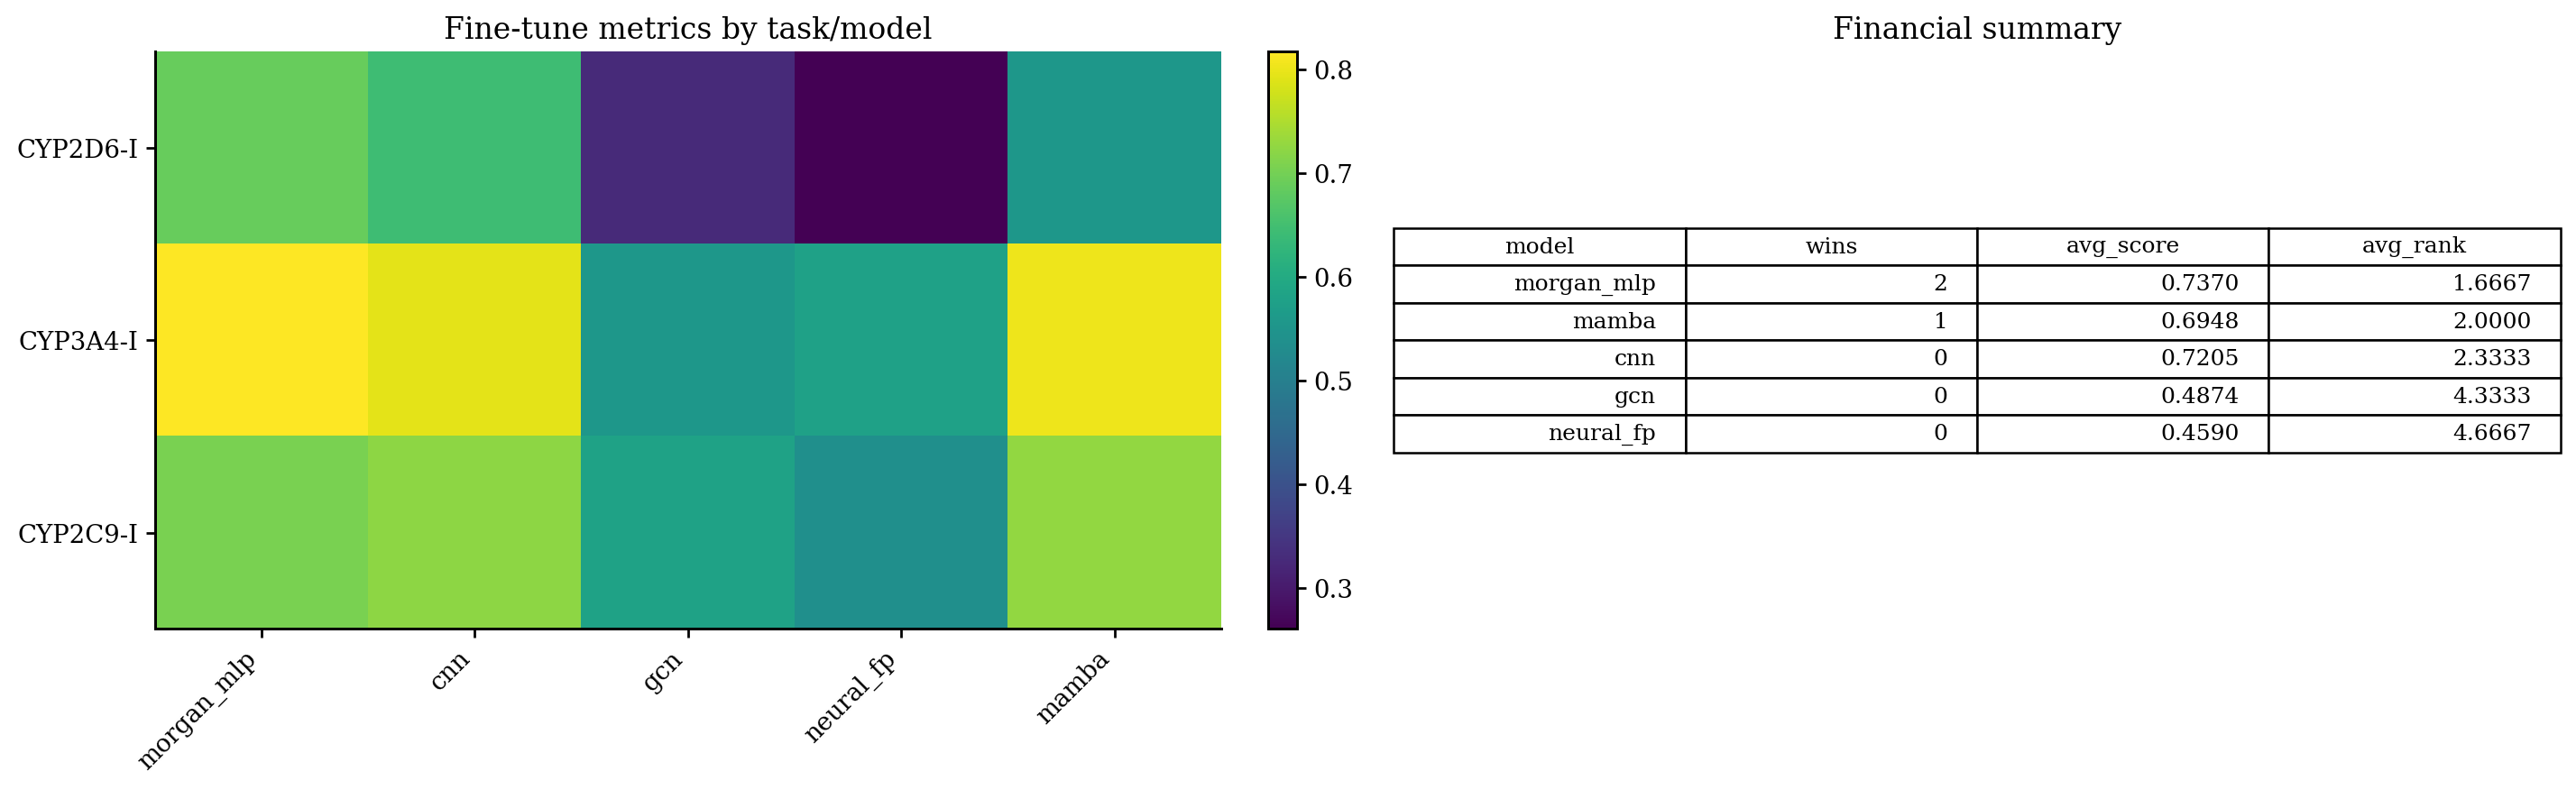

In [72]:
results_df, financial_df, fine_tune_cache = main(selected_tasks=['CYP2D6-I', 'CYP3A4-I', 'CYP2C9-I'])
plot_financial_results(results_df, financial_df)

Found local copy...
Loading...
Done!


Словарь Mamba загружен! Размер: 62
Tasks scheduled: ['BBB', 'PPBR', 'VD', 'CYP2D6-I', 'CYP3A4-I', 'CYP2C9-I', 'CYP2D6-S', 'CYP3A4-S', 'CYP2C9-S', 'Half-Life', 'CL-Micro', 'CL-Hepa', 'hERG', 'AMES', 'DILI', 'LD50', 'Caco2', 'HIA', 'Pgp', 'Bioav', 'Lipo', 'AqSol']


100%|██████████| 2030/2030 [00:01<00:00, 1296.33it/s]
2026-04-19 20:35:08,304 - INFO - Using cached fine-tune result for BBB | morgan_mlp
2026-04-19 20:35:08,305 - INFO - Using cached fine-tune result for BBB | cnn
2026-04-19 20:35:08,306 - INFO - Using cached fine-tune result for BBB | gcn
2026-04-19 20:35:08,306 - INFO - Using cached fine-tune result for BBB | neural_fp
2026-04-19 20:35:08,307 - INFO - Using cached fine-tune result for BBB | mamba
Downloading...
100%|██████████| 265k/265k [00:00<00:00, 368kiB/s]  
Loading...
Done!
100%|██████████| 1614/1614 [00:01<00:00, 1201.32it/s]
2026-04-19 20:35:11,842 - INFO - Using cached fine-tune result for PPBR | morgan_mlp
2026-04-19 20:35:11,843 - INFO - Using cached fine-tune result for PPBR | cnn
2026-04-19 20:35:11,844 - INFO - Using cached fine-tune result for PPBR | gcn
2026-04-19 20:35:11,845 - INFO - Using cached fine-tune result for PPBR | neural_fp
2026-04-19 20:35:11,846 - INFO - Using cached fine-tune result for PPBR | mamba
Do

FINAL RESULTS SUMMARY (Best Test Metrics)
Task            | Metric    | morgan_mlp |        cnn |        gcn |  neural_fp |      mamba
--------------------------------------------------------------------------------------------
CL-Hepa         | SPEARMAN  |     0.3379 |     0.2576 |     0.0109 |    -0.0191 |     0.1837 | 
hERG            | ROC-AUC   |     0.8094 |     0.6631 |     0.6313 |     0.6188 |     0.7181 | 
AMES            | ROC-AUC   |     0.7851 |     0.8033 |     0.7309 |     0.6192 |     0.8084 | 
DILI            | ROC-AUC   |     0.7934 |     0.8420 |     0.7778 |     0.6406 |     0.9045 | 
LD50            | MAE       |     0.5505 |     0.5764 |     0.7691 |     0.7076 |     0.5247 | 
Caco2           | MAE       |     0.4620 |     0.4269 |     1.0673 |     1.0135 |     0.4665 | 
HIA             | ROC-AUC   |     0.7970 |     0.8333 |     0.7091 |     0.6530 |     0.9152 | 
Pgp             | ROC-AUC   |     0.9174 |     0.8483 |     0.7385 |     0.8022 |     0.8843 | 
Bioa

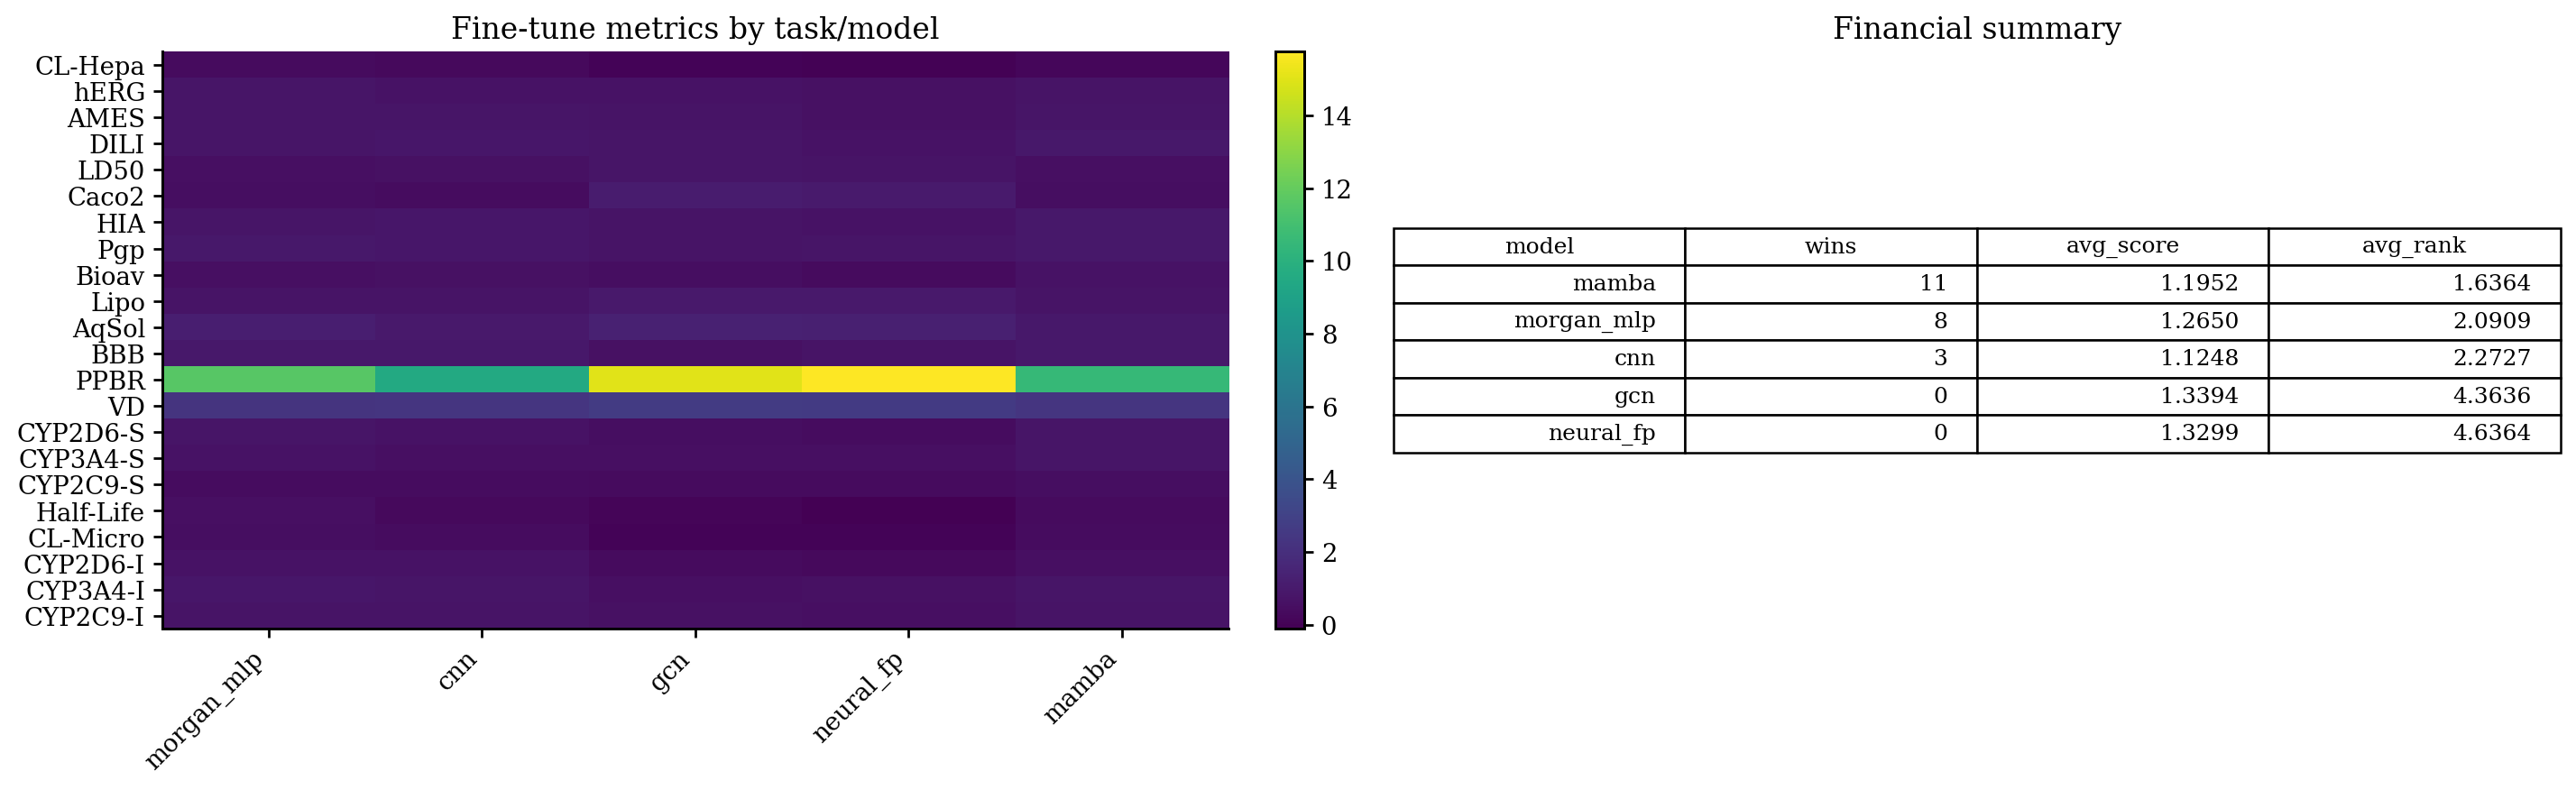

In [73]:
results_df, financial_df, fine_tune_cache = main()
plot_financial_results(results_df, financial_df)

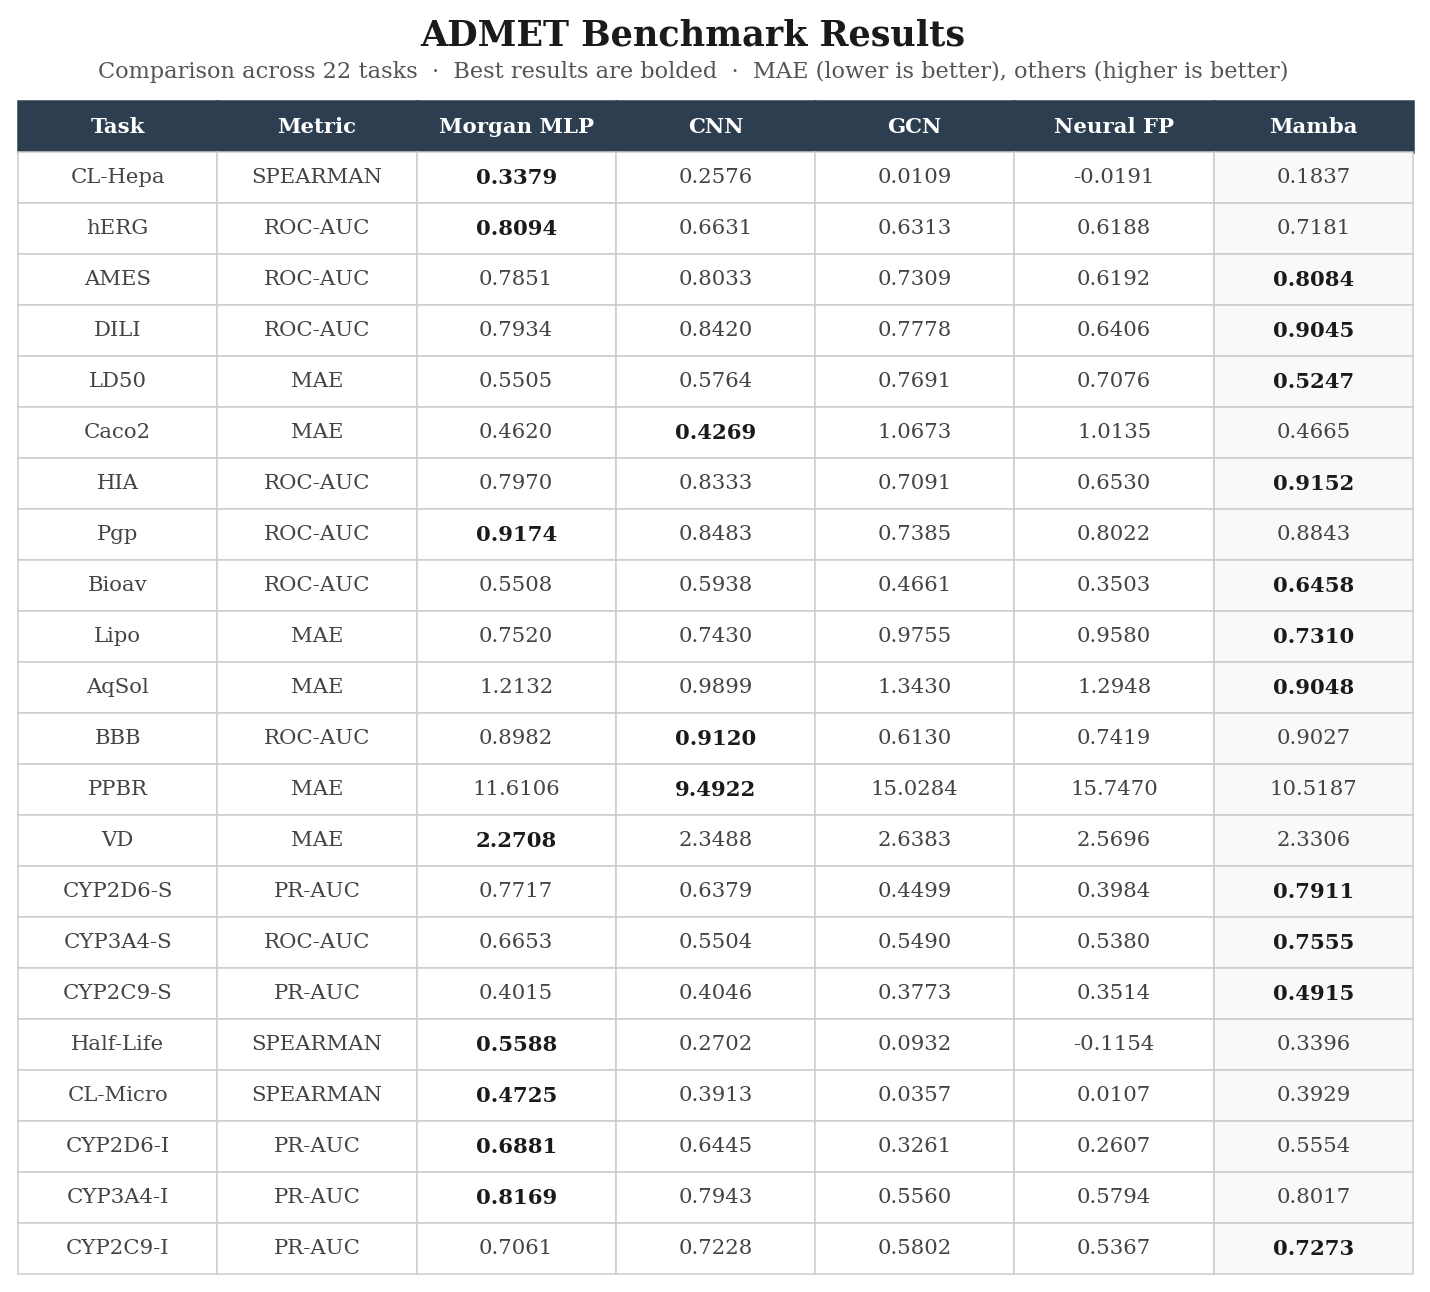

In [ ]:
data = [
    ["CL-Hepa",    "SPEARMAN", 0.3379, 0.2576, 0.0109, -0.0191, 0.1837],
    ["hERG",       "ROC-AUC",  0.8094, 0.6631, 0.6313, 0.6188, 0.7181],
    ["AMES",       "ROC-AUC",  0.7851, 0.8033, 0.7309, 0.6192, 0.8084],
    ["DILI",       "ROC-AUC",  0.7934, 0.8420, 0.7778, 0.6406, 0.9045],
    ["LD50",       "MAE",      0.5505, 0.5764, 0.7691, 0.7076, 0.5247],
    ["Caco2",      "MAE",      0.4620, 0.4269, 1.0673, 1.0135, 0.4665],
    ["HIA",        "ROC-AUC",  0.7970, 0.8333, 0.7091, 0.6530, 0.9152],
    ["Pgp",        "ROC-AUC",  0.9174, 0.8483, 0.7385, 0.8022, 0.8843],
    ["Bioav",      "ROC-AUC",  0.5508, 0.5938, 0.4661, 0.3503, 0.6458],
    ["Lipo",       "MAE",      0.7520, 0.7430, 0.9755, 0.9580, 0.7310],
    ["AqSol",      "MAE",      1.2132, 0.9899, 1.3430, 1.2948, 0.9048],
    ["BBB",        "ROC-AUC",  0.8982, 0.9120, 0.6130, 0.7419, 0.9027],
    ["PPBR",       "MAE",      11.6106, 9.4922, 15.0284, 15.7470, 10.5187],
    ["VD",         "MAE",      2.2708, 2.3488, 2.6383, 2.5696, 2.3306],
    ["CYP2D6-S",   "PR-AUC",   0.7717, 0.6379, 0.4499, 0.3984, 0.7911],
    ["CYP3A4-S",   "ROC-AUC",  0.6653, 0.5504, 0.5490, 0.5380, 0.7555],
    ["CYP2C9-S",   "PR-AUC",   0.4015, 0.4046, 0.3773, 0.3514, 0.4915],
    ["Half-Life",  "SPEARMAN", 0.5588, 0.2702, 0.0932, -0.1154, 0.3396],
    ["CL-Micro",   "SPEARMAN", 0.4725, 0.3913, 0.0357, 0.0107, 0.3929],
    ["CYP2D6-I",   "PR-AUC",   0.6881, 0.6445, 0.3261, 0.2607, 0.5554],
    ["CYP3A4-I",   "PR-AUC",   0.8169, 0.7943, 0.5560, 0.5794, 0.8017],
    ["CYP2C9-I",   "PR-AUC",   0.7061, 0.7228, 0.5802, 0.5367, 0.7273],
]

columns = ["Task", "Metric", "Morgan MLP", "CNN", "GCN", "Neural FP", "Mamba"]

cell_text = []
for row in data:
    formatted_row = [
        f"{val:.4f}" if isinstance(val, float) else str(val) 
        for val in row
    ]
    cell_text.append(formatted_row)

plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["DejaVu Serif"],
    "font.size":          10,
    "figure.dpi":         180,
})

fig, ax = plt.subplots(figsize=(10, 8))
ax.axis('off')

table = ax.table(
    cellText=cell_text, 
    colLabels=columns, 
    loc='center', 
    cellLoc='center'
)


table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.7)

for i, row_data in enumerate(data):
    vals = row_data[2:]
    metric = row_data[1]
    best_val_in_row = min(vals) if metric == "MAE" else max(vals)
    
    for j, val in enumerate(row_data):
        cell = table[i + 1, j]

        cell.set_linewidth(0.6)
        cell.set_edgecolor("#CCCCCC")
        
        if isinstance(val, (float, int)) and val == best_val_in_row:
            cell.get_text().set_fontweight('bold')
            cell.get_text().set_color("#1a1a1a")
        else:
            cell.get_text().set_color("#444444")
            
        if j == 6:
            cell.set_facecolor("#F8F9F9")
        else:
            cell.set_facecolor("white")

for j in range(len(columns)):
    cell = table[0, j]
    cell.get_text().set_fontweight('bold')
    cell.get_text().set_color("white")
    cell.set_facecolor("#2C3E50")
    cell.set_edgecolor("#2C3E50")


fig.text(
    0.5, 0.96,
    "ADMET Benchmark Results",
    ha="center", va="top",
    fontsize=14, fontweight="bold", color="#1a1a1a",
)
fig.text(
    0.5, 0.93,
    "Comparison across 22 tasks  ·  Best results are bolded  ·  MAE (lower is better), others (higher is better)",
    ha="center", va="top",
    fontsize=9, color="#555555",
)

plt.show()